# Heart Disease Prediction & Clinical Risk Stratification

## Project Overview
This project builds a robust, interpretable, and clinically actionable machine learning pipeline for predicting **heart disease** (coronary heart disease, angina, heart attack and congestive heart failure) from demographic, vital-sign, laboratory, lifestyle and chest-pain symptom data. The goal is not only to classify patients as healthy or at-risk, but to make every prediction explainable, reliable and deployable in a medical setting. It follows the same end-to-end workflow as the kidney (CKD) and lung (COPD) notebooks, including their benchmark of modern tabular models.

**Dataset:** `HEART_NHANES.csv`, built from six public CDC NHANES survey cycles (2007–2020): **24,454 examined adults aged 40+**, 34 columns, **12.5 % heart disease prevalence**. It replaces the 920-patient UCI heart disease file used previously. That is 27× more patients, and it adds measured labs (HbA1c, creatinine, urine albumin, blood counts) that the UCI file lacks. The data dictionary is in `data/README.md`, and `data/build_heart_nhanes.py` rebuilds the file from the CDC servers.

## Key Highlights
* **Leakage-aware preprocessing:** survey skip patterns are resolved at build time (a patient who never had chest pain has chest-pain type "No pain", not a missing value). Features are scaled *before* KNN imputation so no single unit dominates the neighbour search, SMOTENC keeps synthetic patients' categorical answers valid, and every fitted step lives inside the cross-validation pipeline.
* **Clinical feature engineering:** pulse pressure, non-HDL cholesterol, the total/HDL cholesterol ratio, waist-to-height ratio, eGFR (CKD-EPI 2021), log urine albumin-to-creatinine ratio and a count of classic risk factors.
* **17 classifiers:** 9 baselines (the original heart models plus LightGBM and SVM, the same set as the kidney notebook) and 8 modern models: CatBoost, Explainable Boosting Machine, TabNet, FT-Transformer, RealMLP, TabM, TabPFN and a Stacking Ensemble.
* **Honest model selection:** hyper-parameters (including *whether to oversample at all*) are tuned on cross-validated PR-AUC. The test set is used only for reporting, and the one-standard-error rule picks the simplest CPU-deployable model when the difference is within noise.
* **Calibration & clinical thresholding:** isotonic calibration and a cost-based threshold (a missed heart disease case costs 5× a false alarm) chosen on out-of-fold *training* predictions, with bootstrapped 95 % confidence intervals.
* **Unsupervised learning, anomaly detection and an explainable two-stage cascade** with SHAP explanations for every prediction.

# Import Libraries

In [1]:
import os
import sys
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
from sklearn.pipeline import Pipeline # Kept for standard preprocessing
from imblearn.pipeline import Pipeline as ImbPipeline # Required for SMOTE integration
from imblearn.over_sampling import SMOTENC # SMOTE for mixed numeric + categorical data

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, precision_score, recall_score,
    f1_score, precision_recall_curve, roc_curve, auc, average_precision_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier # Advanced Gradient Boosting
from lightgbm import LGBMClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

import torch

RANDOM_STATE = 42
N_JOBS = int(os.environ.get('N_JOBS', max(1, (os.cpu_count() or 2) - 2)))   # leave two cores for the OS (N_JOBS env var overrides)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'     # GPU for the deep tabular models

# KNNImputer builds patient-to-patient distance matrices; smaller chunks keep N_JOBS parallel workers within 16 GB of RAM
set_config(working_memory=256)

def keep_workers_light():
    # scikit-learn copies the warning filters into every parallel worker. torch and lightning register filters for their
    # own warning classes, so each worker would import torch + CUDA (~1.5 GB of RAM). Keep only light libraries' filters.
    light_libraries = ('builtins', 'warnings', 'numpy', 'scipy', 'pandas', 'sklearn')
    warnings.filters[:] = [f for f in warnings.filters if f[2].__module__.split('.')[0] in light_libraries]

keep_workers_light()
print(f"CPU workers: {N_JOBS} | Deep-learning device: {DEVICE}")

CPU workers: 10 | Deep-learning device: cuda


# Database Load & Analysis

In [2]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    project_dir = "/content/drive/MyDrive/AI Projects/Heart Diseases/"
else:
    project_dir = os.path.abspath("..")          # heart/tabular/ — this notebook lives in notebook/

data_folder = os.path.join(project_dir, "data")
images_dir = os.path.join(project_dir, "images")
results_dir = os.path.join(project_dir, "results")
models_dir = os.path.join(project_dir, "models")
for folder in (images_dir, results_dir, models_dir):
    os.makedirs(folder, exist_ok=True)

def save_figure(filename):
    # Keep a copy of the key plots in images/ for the README
    plt.savefig(os.path.join(images_dir, filename), dpi=110, bbox_inches='tight')

In [3]:
csv_filename = "HEART_NHANES.csv"

if os.path.exists(data_folder):
    print(f"Files located in '{data_folder}':")
    print(os.listdir(data_folder))
    print("=" * 60)
else:
    print(f"⚠️ Directory not found: {data_folder}")

try:
    heart_data = pd.read_csv(os.path.join(data_folder, csv_filename))

    print("\n DATASET PREVIEW (First 5 Rows):")
    display(heart_data.head())

    print("\n DATASET STRUCTURE:")
    heart_data.info()

    print("\n STATISTICAL SUMMARY (Transposed):")
    display(heart_data.describe().T)

except FileNotFoundError:
    print(f"\n❌ ERROR: Could not find '{csv_filename}'.")
    print("Rebuild it from CDC NHANES with: python data/build_heart_nhanes.py (run from heart/tabular/)")

Files located in 'E:\Disease-Risk-Prediction\heart\tabular\data':
['build_heart_nhanes.py', 'HEART_NHANES.csv', 'raw', 'README.md']

 DATASET PREVIEW (First 5 Rows):


,participant_id,survey_cycle,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,waist_cm,height_cm,...,hypertension_history,high_cholesterol_history,diabetes_status,stroke_history,family_history_chd,general_health,chest_pain_type,severe_chest_pain,sob_on_exertion,heart_disease
0,41475,2007-2008,62.0,Female,Other/Multi-Racial,3.0,1.83,58.04,156.3,154.7,...,Yes,No,No,No,No,4.0,Non-exertional,No,Yes,1
1,41477,2007-2008,71.0,Male,Non-Hispanic White,3.0,1.50,30.05,109.5,167.1,...,Yes,Yes,Yes,No,No,3.0,No pain,No,No,0
2,41479,2007-2008,52.0,Male,Mexican American,1.0,2.20,27.56,95.4,154.4,...,No,No,No,No,No,3.0,No pain,No,No,0
3,41482,2007-2008,64.0,Male,Mexican American,2.0,4.01,33.64,117.0,173.8,...,Yes,No,No,No,No,4.0,No pain,No,Yes,0
4,41483,2007-2008,66.0,Male,Non-Hispanic Black,4.0,1.14,44.06,145.6,173.8,...,Yes,Yes,Yes,No,No,4.0,Non-exertional,No,No,0



 DATASET STRUCTURE:
<class 'pandas.DataFrame'>
RangeIndex: 24454 entries, 0 to 24453
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            24454 non-null  int64  
 1   survey_cycle              24454 non-null  str    
 2   age                       24454 non-null  float64
 3   gender                    24454 non-null  str    
 4   ethnicity                 24454 non-null  str    
 5   education_level           24420 non-null  float64
 6   poverty_income_ratio      21844 non-null  float64
 7   bmi                       24009 non-null  float64
 8   waist_cm                  22835 non-null  float64
 9   height_cm                 24067 non-null  float64
 10  systolic_bp               23161 non-null  float64
 11  diastolic_bp              23081 non-null  float64
 12  resting_heart_rate        22734 non-null  float64
 13  total_cholesterol         22944 non-null  float64
 

,count,mean,std,min,25%,50%,75%,max
participant_id,24454.0,79165.905373,25300.396220,41475.00,57665.50,76223.50,93086.75,124822.00
age,24454.0,59.796843,12.175063,40.00,49.00,60.00,70.00,80.00
education_level,24420.0,3.336036,1.312078,1.00,2.00,4.00,4.00,5.00
poverty_income_ratio,21844.0,2.593707,1.630669,0.00,1.16,2.19,4.25,5.00
bmi,24009.0,29.622290,6.838098,13.18,25.00,28.57,33.00,84.87
waist_cm,22835.0,101.689315,15.602701,56.20,91.00,100.40,110.80,187.50
height_cm,24067.0,166.142114,10.162063,123.30,158.70,165.80,173.40,203.80
systolic_bp,23161.0,128.676836,19.516610,64.70,115.30,126.00,139.30,234.70
diastolic_bp,23081.0,72.093458,12.153173,3.30,64.70,72.00,79.70,143.70
resting_heart_rate,22734.0,71.385915,12.051770,36.00,62.30,70.00,78.00,160.00


### Dataset Distribution

In [4]:
print(heart_data['heart_disease'].value_counts(dropna=False))
print(f"\nHeart disease prevalence: {heart_data['heart_disease'].mean():.2%}")
heart_data = heart_data.dropna(subset=['heart_disease'])   # Remove rows without a label (none expected)

heart_disease
0    21403
1     3051
Name: count, dtype: int64

Heart disease prevalence: 12.48%


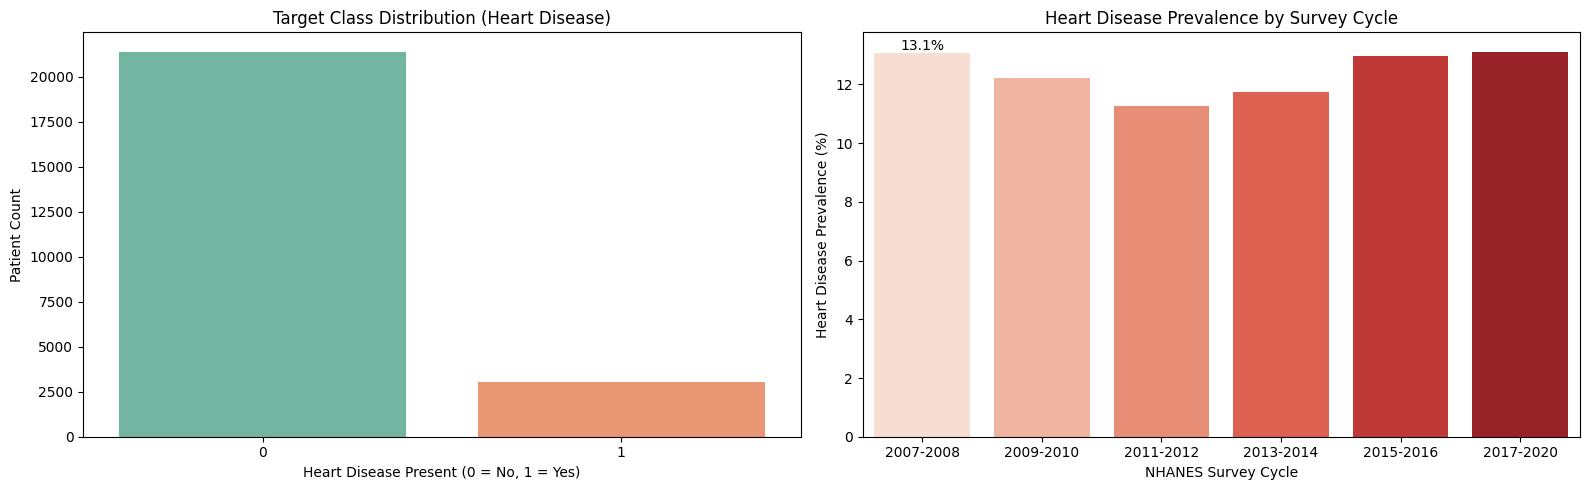

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x="heart_disease", data=heart_data, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Heart Disease Present (0 = No, 1 = Yes)")
axes[0].set_ylabel("Patient Count")
axes[0].set_title("Target Class Distribution (Heart Disease)")

# Label-drift check: six survey cycles pooled; the diagnosis questions are identical in each
cycle_prevalence = heart_data.groupby('survey_cycle')['heart_disease'].mean() * 100
sns.barplot(x=cycle_prevalence.index, y=cycle_prevalence.values, palette="Reds", ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%')
axes[1].set_xlabel("NHANES Survey Cycle")
axes[1].set_ylabel("Heart Disease Prevalence (%)")
axes[1].set_title("Heart Disease Prevalence by Survey Cycle")

plt.tight_layout()
save_figure("target_distribution.png")
plt.show()

* **3,051 of 24,454 patients (12.5 %) have heart disease**, a 7:1 imbalance. A model that calls everyone healthy would already be 87.5 % accurate, which is why accuracy is not used to choose models.
* **Prevalence is stable across the six survey cycles (11.3 % to 13.1 %).** The four diagnosis questions were asked the same way in every cycle, so pooling the cycles doesn't mix different label definitions.

### Missing Values & Survey Skip Patterns
NHANES skips questions that do not apply. A participant who has never had chest pain is not asked whether the pain comes on with exertion, or whether it ever lasted 30 minutes. Left as blanks, a KNN imputer would *invent* chest-pain answers for 18,000 pain-free patients. The build script already turned those structural gaps into true answers ("No pain", "No") and refused / don't-know codes into NaN, so every blank left in the table is a genuine unknown. The checks below verify that before any modelling.

The chest-pain questions come from the **Rose angina questionnaire**, the survey counterpart of the UCI dataset's chest-pain type (`cp`) and exercise-induced angina (`exang`).

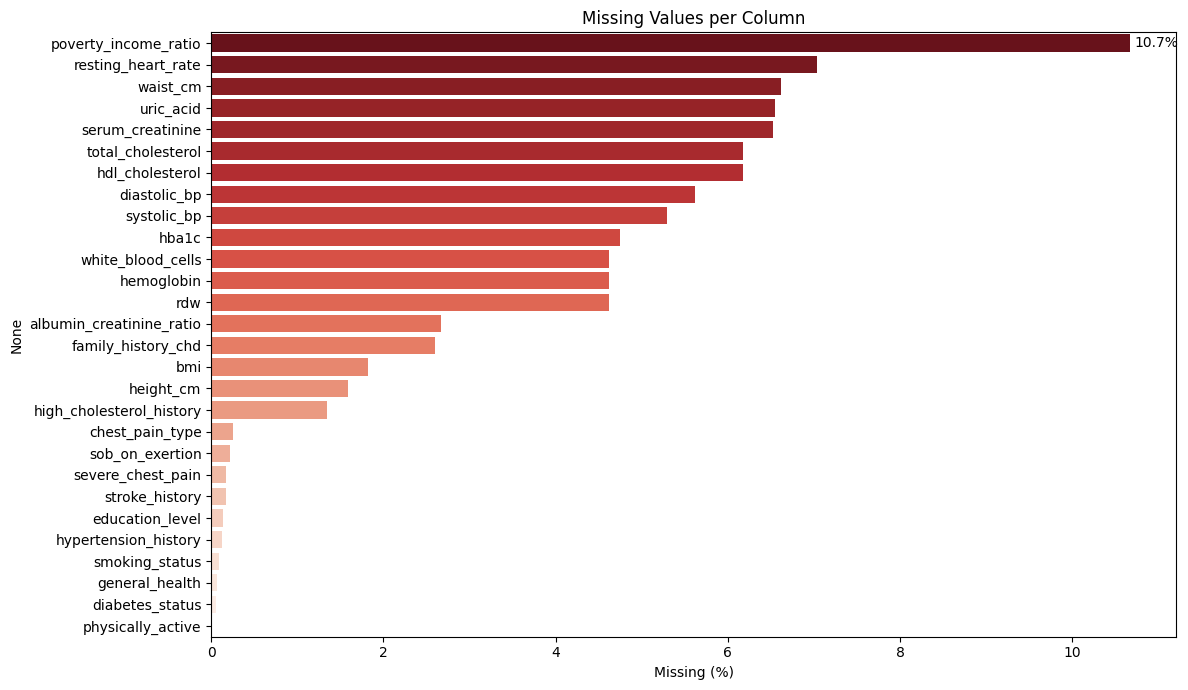

Patients who never had chest pain: 18,002
  with severe chest pain recorded as 'Yes' (must be 0) : 0
  with severe chest pain left blank (must be 0)        : 0
Rows where HDL exceeds total cholesterol: 0

Heart disease prevalence by chest-pain type (Rose questionnaire):
chest_pain_type
No pain            6.5 %
Non-exertional    24.3 %
Exertional        39.8 %

Heart disease prevalence by age band:
age
40-49     3.5 %
50-59     7.4 %
60-69    13.9 %
70-80    24.9 %


In [6]:
missing = (heart_data.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlabel("Missing (%)")
plt.title("Missing Values per Column")
plt.tight_layout()
save_figure("missing_values.png")
plt.show()

no_pain = heart_data[heart_data['chest_pain_type'] == 'No pain']
print(f"Patients who never had chest pain: {len(no_pain):,}")
print(f"  with severe chest pain recorded as 'Yes' (must be 0) : {(no_pain['severe_chest_pain'] == 'Yes').sum()}")
print(f"  with severe chest pain left blank (must be 0)        : {no_pain['severe_chest_pain'].isna().sum()}")
print(f"Rows where HDL exceeds total cholesterol: {(heart_data['hdl_cholesterol'] > heart_data['total_cholesterol']).sum()}")

print("\nHeart disease prevalence by chest-pain type (Rose questionnaire):")
print((heart_data.groupby('chest_pain_type')['heart_disease'].mean() * 100).round(1).sort_values().astype(str).add(' %').to_string())

print("\nHeart disease prevalence by age band:")
age_bands = pd.cut(heart_data['age'], bins=[39, 49, 59, 69, 80], labels=['40-49', '50-59', '60-69', '70-80'])
print((heart_data.groupby(age_bands, observed=True)['heart_disease'].mean() * 100).round(1).astype(str).add(' %').to_string())

* **Every blank is a genuine unknown.** None of the 18,002 pain-free patients has a severe-chest-pain answer of "Yes" or a blank, and no row has HDL above total cholesterol.
* **Missingness is modest.** The most incomplete column is the poverty-income ratio (10.7 %), then resting heart rate (7.0 %), waist (6.6 %), creatinine and uric acid (6.5 %) and cholesterol (6.2 %). Questionnaire answers are almost complete (family history 2.6 %, everything else ≤ 1.3 %), so KNN imputation fills only a small share of values.
* **Chest-pain type is a strong signal on its own.** Heart disease prevalence is 6.5 % without chest pain, 24.3 % with non-exertional pain and 39.8 % with exertional pain, a 6× gradient. Exertional pain is the survey counterpart of the UCI dataset's "typical angina".
* **Risk climbs steeply with age:** 3.5 % at 40–49, 7.4 % at 50–59, 13.9 % at 60–69 and 24.9 % at 70–80.

### Correlation Analysis

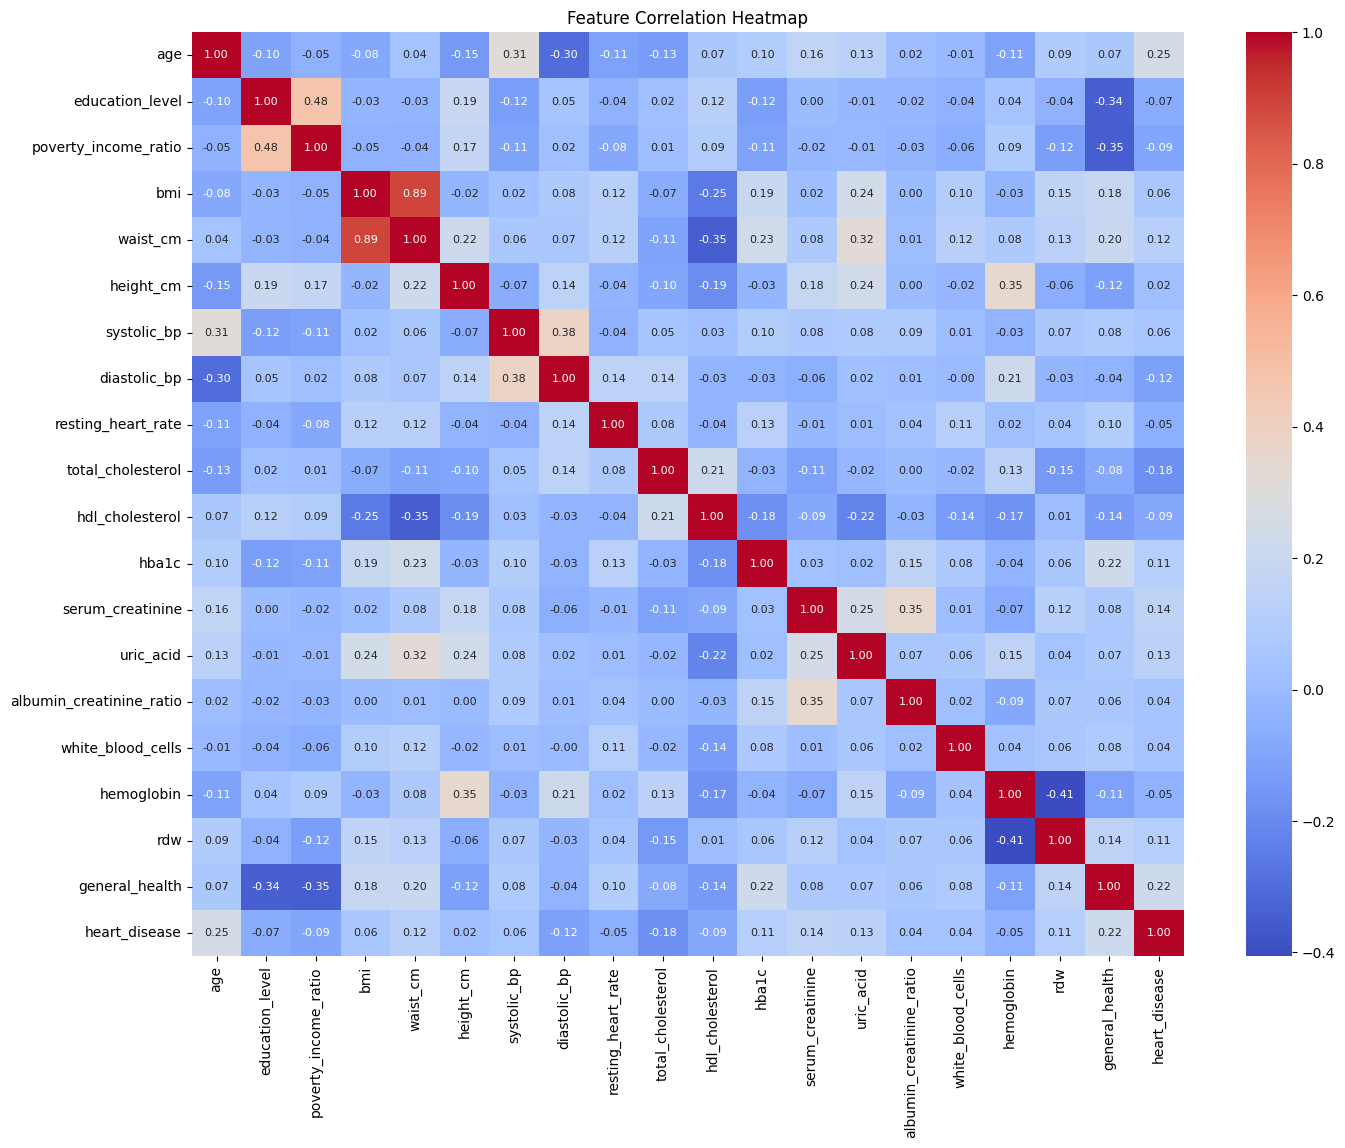

In [7]:
# Drop the identifier and survey metadata — they describe the survey, not the patient
heart_data = heart_data.drop(columns=['participant_id', 'survey_cycle'], errors='ignore')

plt.figure(figsize=(16, 12))
sns.heatmap(heart_data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={'size': 8})
plt.title("Feature Correlation Heatmap")
save_figure("correlation_heatmap.png")
plt.show()

* **Age (r = +0.25) and self-rated general health (+0.22)** are the strongest single correlates of heart disease, followed by kidney and metabolic markers: creatinine (+0.14), uric acid (+0.13), waist (+0.12), RDW (+0.11) and HbA1c (+0.11).
* **Total cholesterol correlates *negatively* with heart disease (r = −0.18)**, the opposite of its causal role. This is a treatment effect of cross-sectional data: many diagnosed patients take statins, so their measured cholesterol is lower. Diastolic pressure is also lower in patients (−0.12), which fits both treatment and the arterial stiffening that comes with age. The model learns *diagnosed* heart disease, treatment included (see the caveats in `data/README.md`).
* **All correlations are weak (|r| ≤ 0.25).** No single measurement separates the classes, so the models have to combine many small signals.
* **Nothing is redundant enough to drop.** The only pair above 0.85 is BMI and waist (r = 0.89), and waist stays because the waist-to-height ratio is built from it.

In [8]:
threshold = 0.85
target = 'heart_disease'

# Inputs of the feature-engineering step must survive the redundancy filter
engineering_inputs = ['age', 'systolic_bp', 'diastolic_bp', 'total_cholesterol', 'hdl_cholesterol',
                      'waist_cm', 'height_cm', 'serum_creatinine', 'albumin_creatinine_ratio']

# The target is excluded: a feature that tracks the label is signal, not redundancy
corr_matrix = heart_data.drop(columns=[target]).corr(numeric_only=True).abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

flagged = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
features_to_drop = [column for column in flagged if column not in engineering_inputs]

print(f"Features highly correlated (>{threshold}) will be dropped: {features_to_drop}")
for column in flagged:
    status = 'dropped' if column in features_to_drop else 'kept (feature-engineering input)'
    print(f"  {column} ~ {upper_triangle[column].idxmax()}: r = {upper_triangle[column].max():.3f} -> {status}")

heart_data = heart_data.drop(columns=features_to_drop)
print("\nRemaining columns in the dataset:")
print(heart_data.columns.tolist())

Features highly correlated (>0.85) will be dropped: []
  waist_cm ~ bmi: r = 0.894 -> kept (feature-engineering input)

Remaining columns in the dataset:
['age', 'gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'bmi', 'waist_cm', 'height_cm', 'systolic_bp', 'diastolic_bp', 'resting_heart_rate', 'total_cholesterol', 'hdl_cholesterol', 'hba1c', 'serum_creatinine', 'uric_acid', 'albumin_creatinine_ratio', 'white_blood_cells', 'hemoglobin', 'rdw', 'smoking_status', 'physically_active', 'hypertension_history', 'high_cholesterol_history', 'diabetes_status', 'stroke_history', 'family_history_chd', 'general_health', 'chest_pain_type', 'severe_chest_pain', 'sob_on_exertion', 'heart_disease']


# Dataset Pre-processing

### Feature Engineering
Seven clinically motivated features. The function is row-wise and stateless (it learns nothing from the data), so it is safe to run on any split. Inside the model it runs as the first pipeline step.

| Feature | Formula | Why |
|---|---|---|
| `pulse_pressure` | systolic − diastolic BP | Arterial stiffness. A wide pulse pressure predicts coronary events beyond systolic BP alone. |
| `non_hdl_cholesterol` | total − HDL cholesterol | All atherogenic cholesterol (LDL, VLDL, remnants). Valid without fasting, unlike LDL. |
| `tc_hdl_ratio` | total ÷ HDL cholesterol | The Castelli risk index, one of the inputs of the QRISK3 score. |
| `waist_to_height_ratio` | waist ÷ height | Central obesity. A ratio ≥ 0.5 flags cardiometabolic risk better than BMI. |
| `egfr` | CKD-EPI 2021 (creatinine, age, sex) | Kidney function. Chronic kidney disease is a major coronary risk factor. |
| `log_acr` | log10(urine albumin ÷ creatinine) | Albuminuria signals vascular (endothelial) damage. ACR spans five orders of magnitude, so the log replaces the raw value. |
| `risk_factor_count` | hypertension + high cholesterol + diabetes + current smoking | The classic modifiable risk-factor burden in one ordinal number. |

In [9]:
def add_custom_features(X_df):
    X_new = X_df.copy()

    # Arterial stiffness: the gap between systolic and diastolic pressure
    X_new['pulse_pressure'] = X_new['systolic_bp'] - X_new['diastolic_bp']

    # Lipid ratios (HDL floored at 10 mg/dL to avoid division by ~0)
    X_new['non_hdl_cholesterol'] = X_new['total_cholesterol'] - X_new['hdl_cholesterol']
    X_new['tc_hdl_ratio'] = X_new['total_cholesterol'] / X_new['hdl_cholesterol'].clip(lower=10)

    # Central obesity
    X_new['waist_to_height_ratio'] = X_new['waist_cm'] / X_new['height_cm']

    # Kidney function: race-free CKD-EPI 2021 creatinine equation (mL/min/1.73 m²)
    female = X_new['gender'].eq('Female')
    kappa = np.where(female, 0.7, 0.9)
    alpha = np.where(female, -0.241, -0.302)
    creatinine_ratio = X_new['serum_creatinine'] / kappa
    X_new['egfr'] = (142 * np.minimum(creatinine_ratio, 1) ** alpha * np.maximum(creatinine_ratio, 1) ** -1.200
                     * 0.9938 ** X_new['age'] * np.where(female, 1.012, 1.0))

    # Log scale for albuminuria; clipped at 0.1 mg/g so the log is always defined
    X_new['log_acr'] = np.log10(X_new['albumin_creatinine_ratio'].clip(lower=0.1))

    # Number of classic modifiable risk factors; unknown only if all four answers are unknown
    risk_answers = X_new[['hypertension_history', 'high_cholesterol_history', 'diabetes_status', 'smoking_status']]
    risk_present = pd.DataFrame({
        'hypertension': X_new['hypertension_history'] == 'Yes',
        'high_cholesterol': X_new['high_cholesterol_history'] == 'Yes',
        'diabetes': X_new['diabetes_status'] == 'Yes',
        'current_smoker': X_new['smoking_status'] == 'Current'
    })
    X_new['risk_factor_count'] = risk_present.sum(axis=1).where(risk_answers.notna().any(axis=1))

    return X_new

feature_engineering = FunctionTransformer(add_custom_features)

# Sanity check on the full table (the pipeline recomputes this inside every CV fold)
engineered_preview = add_custom_features(heart_data)
engineered_cols = ['pulse_pressure', 'non_hdl_cholesterol', 'tc_hdl_ratio', 'waist_to_height_ratio', 'egfr', 'log_acr', 'risk_factor_count']
print("Median of each engineered feature by heart disease status:")
display(engineered_preview.groupby('heart_disease')[engineered_cols].median().round(2)
        .rename(index={0: 'No Heart Disease', 1: 'Heart Disease'}))
low_egfr = engineered_preview['egfr'] < 60
print(f"eGFR < 60 (CKD stage 3+): {low_egfr.mean():.1%} of patients | heart disease rate among them: "
      f"{engineered_preview.loc[low_egfr, 'heart_disease'].mean():.1%} vs {engineered_preview.loc[~low_egfr, 'heart_disease'].mean():.1%} otherwise")

Median of each engineered feature by heart disease status:


,pulse_pressure,non_hdl_cholesterol,tc_hdl_ratio,waist_to_height_ratio,egfr,log_acr,risk_factor_count
heart_disease,,,,,,,
No Heart Disease,52.0,141.0,3.71,0.60,91.02,0.90,1.0
Heart Disease,60.0,118.0,3.54,0.63,74.19,1.14,2.0


eGFR < 60 (CKD stage 3+): 11.0% of patients | heart disease rate among them: 30.1% vs 10.3% otherwise


### Preprocessing
The pipeline order matters, and differs from the original heart notebook in three deliberate ways:

1. **Scale → impute** (not impute → scale). `KNNImputer` finds neighbours by Euclidean distance. On raw units, the poverty ratio (0–5) would count for nothing next to cholesterol in mg/dL. `RobustScaler` ignores NaNs while fitting, so it can run first.
2. **SMOTENC instead of SMOTE, before one-hot encoding.** Plain SMOTE after one-hot encoding interpolates the dummy columns and creates patients with "0.4 current smoker" or "0.3 exertional chest pain". SMOTENC interpolates only the numeric features and copies categorical answers from real neighbours.
3. **Oversampling is optional.** `'smote'` is a pipeline step that the grid search may switch off (`'passthrough'`).

The train/test split happens before anything is fitted, and all fitted steps (scaler, imputer, SMOTENC, encoder) live inside the pipeline, so they are re-fitted on each CV training fold only.

In [10]:
X = heart_data.drop(columns=['heart_disease'])
y = heart_data['heart_disease']   # Already 0 and 1

categorical_features = X.select_dtypes(exclude='number').columns.tolist()
numerical_existing_features = X.select_dtypes(include='number').columns.tolist()

# Engineered features join the numeric block; the log replaces the raw albumin-creatinine ratio
engineered_features = ['pulse_pressure', 'non_hdl_cholesterol', 'tc_hdl_ratio', 'waist_to_height_ratio',
                       'egfr', 'log_acr', 'risk_factor_count']
numerical_features = [c for c in numerical_existing_features if c != 'albumin_creatinine_ratio'] + engineered_features

numeric_sub_pipeline = Pipeline(steps=[
    ('scaler', RobustScaler()),                 # Scale first so every feature counts equally in KNN distances
    ('imputer', KNNImputer(n_neighbors=5))      # Impute missing clinical values from the 5 most similar patients
])

imputation = ColumnTransformer(
    transformers=[
        ('num_transform', numeric_sub_pipeline, numerical_features),
        ('cat_transform', SimpleImputer(strategy='most_frequent'), categorical_features)
    ],
    verbose_feature_names_out=False
).set_output(transform='pandas')                # keep column names so SMOTENC can find the categoricals

encoding = ColumnTransformer(
    transformers=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)],
    remainder='passthrough',                    # numeric block is already scaled + imputed
    verbose_feature_names_out=False
)

# Interpolates numeric features, copies categories from real neighbours
smote = SMOTENC(categorical_features=categorical_features, random_state=RANDOM_STATE)

def build_pipeline(classifier, oversample=True):
    # feature engineering -> scale + impute -> (SMOTENC) -> one-hot -> classifier
    return ImbPipeline(steps=[
        ('engineering', clone(feature_engineering)),
        ('imputation', clone(imputation)),
        ('smote', clone(smote) if oversample else 'passthrough'),
        ('encoding', clone(encoding)),
        ('classifier', classifier)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # Cross-Validation

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nX_train shape: {X_train.shape} | Heart disease cases: {y_train.sum():,} ({y_train.mean():.1%})")
print(f"X_test shape: {X_test.shape} | Heart disease cases: {y_test.sum():,} ({y_test.mean():.1%})")
print("Preprocessing pipeline configured successfully with advanced features!")

Numerical features (25): ['age', 'education_level', 'poverty_income_ratio', 'bmi', 'waist_cm', 'height_cm', 'systolic_bp', 'diastolic_bp', 'resting_heart_rate', 'total_cholesterol', 'hdl_cholesterol', 'hba1c', 'serum_creatinine', 'uric_acid', 'white_blood_cells', 'hemoglobin', 'rdw', 'general_health', 'pulse_pressure', 'non_hdl_cholesterol', 'tc_hdl_ratio', 'waist_to_height_ratio', 'egfr', 'log_acr', 'risk_factor_count']
Categorical features (12): ['gender', 'ethnicity', 'smoking_status', 'physically_active', 'hypertension_history', 'high_cholesterol_history', 'diabetes_status', 'stroke_history', 'family_history_chd', 'chest_pain_type', 'severe_chest_pain', 'sob_on_exertion']

X_train shape: (19563, 31) | Heart disease cases: 2,441 (12.5%)
X_test shape: (4891, 31) | Heart disease cases: 610 (12.5%)
Preprocessing pipeline configured successfully with advanced features!


# Model Training

### Model Training Setup
**Tuning metric: PR-AUC (average precision), not recall.** At 12.5 % prevalence, recall on its own can be maximised by a model that calls almost everyone sick, and a grid search on `scoring='recall'` (as in the original heart notebook) rewards exactly that. PR-AUC measures how well a model ranks real heart disease cases above healthy patients across *all* thresholds, and the clinical recall target is enforced later by the cost-based threshold. For reference, a random model scores PR-AUC ≈ 0.125 (the prevalence).

**Oversampling is tuned, not assumed.** Every grid includes `smote: [SMOTENC, 'passthrough']`, so cross-validation decides per model whether synthetic minority samples help.

The classification report under each model is on the held-out test set at the default 0.5 threshold. Models trained without SMOTE rarely reach 0.5 at 12.5 % prevalence, so their recall there looks low. The threshold is fixed properly in the *Threshold Analysis* section.

In [11]:
target_classes = ['Healthy', 'Heart Disease']
SMOTE_OPTIONS = [smote, 'passthrough']      # oversampling on / off, chosen by cross-validation

fitted_models = {}    # model name -> best pipeline, refit on the full training set
cv_summary = {}       # model name -> cross-validated PR-AUC of the chosen settings

def run_grid_search(name, estimator, param_grid, n_jobs=N_JOBS):
    # Tune on 5-fold CV PR-AUC (training data only), then report once on the untouched test set
    start = time.time()
    grid = GridSearchCV(estimator=estimator, param_grid=param_grid, cv=cv_strategy,
                        scoring='average_precision', n_jobs=n_jobs)
    grid.fit(X_train, y_train)
    minutes = (time.time() - start) / 60

    failed = int(np.isnan(grid.cv_results_['mean_test_score']).sum())
    if failed:
        print(f"⚠️ {failed} of {len(grid.cv_results_['params'])} settings failed to fit and were skipped")

    fold_scores = np.array([grid.cv_results_[f'split{k}_test_score'][grid.best_index_]
                            for k in range(cv_strategy.get_n_splits())])
    steps = getattr(grid.best_estimator_, 'named_steps', {})
    smote_used = 'per base model' if 'smote' not in steps else ('on' if steps['smote'] != 'passthrough' else 'off')

    fitted_models[name] = grid.best_estimator_
    cv_summary[name] = {'CV PR-AUC': fold_scores.mean(),
                        'CV SE': fold_scores.std(ddof=1) / np.sqrt(len(fold_scores)),
                        'SMOTE': smote_used, 'Tuning Time (min)': minutes}

    best_params = {k.replace('classifier__', ''): v for k, v in grid.best_params_.items() if k != 'smote'}
    print(f"{name} Best CV PR-AUC: {fold_scores.mean():.4f} (± {cv_summary[name]['CV SE']:.4f} SE) | "
          f"SMOTE: {smote_used} | {minutes:.1f} min")
    print(f"Best params: {best_params}\n")
    print(classification_report(y_test, grid.predict(X_test), target_names=target_classes, zero_division=0))
    return grid

### Logistic Regression

In [12]:
lr_pipeline = build_pipeline(LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))

lr_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],     # Regularization strength (smaller = stronger penalty)
    'classifier__l1_ratio': [0.0, 1.0]                  # 0 = L2 (ridge), 1 = L1 (lasso)
}
lr_grid = run_grid_search('Logistic Regression', lr_pipeline, lr_param_grid)

Logistic Regression Best CV PR-AUC: 0.5667 (± 0.0115 SE) | SMOTE: off | 5.3 min
Best params: {'C': 100.0, 'l1_ratio': 0.0}

               precision    recall  f1-score   support

      Healthy       0.91      0.97      0.94      4281
Heart Disease       0.65      0.34      0.45       610

     accuracy                           0.89      4891
    macro avg       0.78      0.66      0.69      4891
 weighted avg       0.88      0.89      0.88      4891



### Naive Bayes

In [13]:
nb_pipeline = build_pipeline(GaussianNB())

nb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__var_smoothing': np.logspace(0, -11, num=25)   # Adds a tiny variance to avoid zero probabilities
}
nb_grid = run_grid_search('Naive Bayes', nb_pipeline, nb_param_grid)

Naive Bayes Best CV PR-AUC: 0.4653 (± 0.0119 SE) | SMOTE: off | 11.7 min
Best params: {'var_smoothing': np.float64(0.00510896977450693)}

               precision    recall  f1-score   support

      Healthy       0.94      0.84      0.89      4281
Heart Disease       0.37      0.63      0.46       610

     accuracy                           0.82      4891
    macro avg       0.65      0.74      0.68      4891
 weighted avg       0.87      0.82      0.84      4891



### K-Nearest Neighbors (KNN)

In [14]:
knn_pipeline = build_pipeline(KNeighborsClassifier())

# Larger k gives smoother probability estimates, which PR-AUC needs
knn_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_neighbors': [5, 11, 21, 51, 101],
    'classifier__weights': ['uniform', 'distance']     # Distance = closer patients count more
}
knn_grid = run_grid_search('KNN', knn_pipeline, knn_param_grid)

KNN Best CV PR-AUC: 0.4946 (± 0.0179 SE) | SMOTE: off | 4.3 min
Best params: {'n_neighbors': 101, 'weights': 'distance'}

               precision    recall  f1-score   support

      Healthy       0.88      1.00      0.93      4281
Heart Disease       0.88      0.02      0.04       610

     accuracy                           0.88      4891
    macro avg       0.88      0.51      0.49      4891
 weighted avg       0.88      0.88      0.82      4891



### Decision Tree

In [15]:
dt_pipeline = build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))

dt_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__max_depth': [3, 5, 8, 12],             # Stops the tree from memorizing patients
    'classifier__min_samples_leaf': [10, 50, 100],
    'classifier__criterion': ['gini', 'entropy']
}
dt_grid = run_grid_search('Decision Tree', dt_pipeline, dt_param_grid)

Decision Tree Best CV PR-AUC: 0.4580 (± 0.0120 SE) | SMOTE: off | 9.5 min
Best params: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 50}

               precision    recall  f1-score   support

      Healthy       0.90      0.97      0.93      4281
Heart Disease       0.55      0.29      0.38       610

     accuracy                           0.88      4891
    macro avg       0.73      0.63      0.66      4891
 weighted avg       0.86      0.88      0.87      4891



### Random Forest

In [16]:
rf_pipeline = build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))

rf_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [8, 16, None],
    'classifier__min_samples_leaf': [5, 20],        # leaves >= 5 keep 400 deep trees within memory across parallel workers
    'classifier__max_features': ['sqrt']
}
rf_grid = run_grid_search('Random Forest', rf_pipeline, rf_param_grid)

Random Forest Best CV PR-AUC: 0.5558 (± 0.0096 SE) | SMOTE: off | 6.6 min
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}

               precision    recall  f1-score   support

      Healthy       0.90      0.99      0.94      4281
Heart Disease       0.70      0.24      0.35       610

     accuracy                           0.89      4891
    macro avg       0.80      0.61      0.65      4891
 weighted avg       0.88      0.89      0.87      4891



### XGBoost

In [17]:
xgb_pipeline = build_pipeline(XGBClassifier(tree_method='hist', random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=1))

xgb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_estimators': [100, 300, 500],        # Number of boosting rounds (trees)
    'classifier__learning_rate': [0.01, 0.05, 0.1],     # How much each tree contributes
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0]                 # Fraction of patients used per tree
}
xgb_grid = run_grid_search('XGBoost', xgb_pipeline, xgb_param_grid)

XGBoost Best CV PR-AUC: 0.5676 (± 0.0131 SE) | SMOTE: off | 25.1 min
Best params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}

               precision    recall  f1-score   support

      Healthy       0.91      0.98      0.94      4281
Heart Disease       0.67      0.34      0.45       610

     accuracy                           0.90      4891
    macro avg       0.79      0.66      0.70      4891
 weighted avg       0.88      0.90      0.88      4891



### LightGBM

In [18]:
lgb_pipeline = build_pipeline(LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1))

lgb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_estimators': [200, 500],
    'classifier__learning_rate': [0.03, 0.1],
    'classifier__num_leaves': [15, 31],
    'classifier__min_child_samples': [20, 100]
}
lgb_grid = run_grid_search('LightGBM', lgb_pipeline, lgb_param_grid)

LightGBM Best CV PR-AUC: 0.5644 (± 0.0134 SE) | SMOTE: off | 6.6 min
Best params: {'learning_rate': 0.03, 'min_child_samples': 100, 'n_estimators': 200, 'num_leaves': 15}

               precision    recall  f1-score   support

      Healthy       0.91      0.98      0.94      4281
Heart Disease       0.68      0.35      0.46       610

     accuracy                           0.90      4891
    macro avg       0.80      0.66      0.70      4891
 weighted avg       0.88      0.90      0.88      4891



### Support Vector Machine (SVM)

In [19]:
# probability=False: PR-AUC only needs the decision function, and Platt scaling would 5x the cost
svm_pipeline = build_pipeline(SVC(kernel='rbf', random_state=RANDOM_STATE))

svm_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__C': [0.1, 1.0, 10.0, 50.0],
    'classifier__gamma': ['scale', 'auto']
}
svm_grid = run_grid_search('SVM', svm_pipeline, svm_param_grid)

SVM Best CV PR-AUC: 0.5473 (± 0.0094 SE) | SMOTE: off | 11.2 min
Best params: {'C': 0.1, 'gamma': 'auto'}

               precision    recall  f1-score   support

      Healthy       0.88      1.00      0.93      4281
Heart Disease       1.00      0.00      0.00       610

     accuracy                           0.88      4891
    macro avg       0.94      0.50      0.47      4891
 weighted avg       0.89      0.88      0.82      4891



### Neural Network (MLP)

In [20]:
mlp_pipeline = build_pipeline(MLPClassifier(max_iter=1000, early_stopping=True, random_state=RANDOM_STATE))

mlp_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__hidden_layer_sizes': [(100,), (100, 50), (128, 64, 32)],
    'classifier__alpha': [0.0001, 0.001, 0.01],         # L2 regularization against overfitting
    'classifier__learning_rate_init': [0.001, 0.01]
}
mlp_grid = run_grid_search('Neural Network (MLP)', mlp_pipeline, mlp_param_grid)

Neural Network (MLP) Best CV PR-AUC: 0.5643 (± 0.0126 SE) | SMOTE: off | 7.5 min
Best params: {'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}

               precision    recall  f1-score   support

      Healthy       0.91      0.97      0.94      4281
Heart Disease       0.65      0.35      0.45       610

     accuracy                           0.90      4891
    macro avg       0.78      0.66      0.70      4891
 weighted avg       0.88      0.90      0.88      4891



# Modern Tabular Models
Eight models beyond the baselines. CatBoost was already in the original heart notebook; the other seven are new. All of them run through the same pipeline and the same CV protocol, so the comparison is like for like.

| Model | Year | Idea |
|---|---|---|
| **CatBoost** | 2018 | Gradient boosting with *ordered boosting*, which removes the target leakage in classic GBDT. |
| **Explainable Boosting Machine (EBM)** | 2019 | A glass-box generalised additive model with pairwise interactions: every feature's effect is a readable curve, which matters in medicine. |
| **TabNet** | 2019 / 2021 | Deep learning with sequential attention that selects which features to use at each decision step. |
| **FT-Transformer** | 2021 | Every feature becomes a token and a Transformer learns the interactions. |
| **RealMLP** | 2024 | An MLP with tuned defaults (robust scaling, smooth clipping, numeric embeddings) that competes with GBDTs. |
| **TabM** | 2025 | Parameter-efficient ensembling: one network trained as many weight-sharing MLPs. |
| **TabPFN** | 2025 | A tabular *foundation model* pre-trained on millions of synthetic datasets that predicts by in-context learning, with no training loop. |
| **Stacking Ensemble** | — | A logistic-regression meta-learner over the best CPU models' out-of-fold predictions. |

GPU models run one fit at a time (`n_jobs=1`) so they don't compete for GPU memory. They are benchmarked exactly like the others, but only CPU models are eligible for deployment (see *Best Supervised Model*). TabPFN is given the original data without SMOTE: it's a Bayesian in-context learner, and synthetic rows would distort the posterior it infers from its context.

In [21]:
# On Colab: !pip install -q catboost interpret-core pytorch-tabnet pytabkit tabpfn
import io
import shutil
import logging
import contextlib
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from pytabkit import RealMLP_TD_Classifier, TabM_D_Classifier, FTT_D_Classifier
from tabpfn import TabPFNClassifier

# The deep-learning libraries log every epoch; keep the notebook readable
for noisy_logger in ('lightning', 'lightning.pytorch', 'pytorch_lightning', 'lightning_fabric'):
    logging.getLogger(noisy_logger).setLevel(logging.ERROR)
keep_workers_light()    # the imports above registered torch / lightning warning filters again

GPU_MODELS = {'TabNet', 'FT-Transformer', 'RealMLP', 'TabM', 'TabPFN'}

def silenced():
    # Swallow console output from libraries that print every epoch
    stack = contextlib.ExitStack()
    stack.enter_context(contextlib.redirect_stdout(io.StringIO()))
    stack.enter_context(contextlib.redirect_stderr(io.StringIO()))
    return stack


class QuietClassifier(ClassifierMixin, BaseEstimator):
    # Wraps a pytabkit deep model: float32 input, no per-epoch logging
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        with silenced():
            self.estimator_ = clone(self.estimator).fit(np.asarray(X, dtype=np.float32), np.asarray(y))
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        with silenced():
            return self.estimator_.predict_proba(np.asarray(X, dtype=np.float32))

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


class TabNetSK(ClassifierMixin, BaseEstimator):
    # scikit-learn wrapper for TabNet that holds out 10 % of the fold for early stopping
    def __init__(self, n_d=8, n_steps=3, gamma=1.3, max_epochs=100, patience=10,
                 batch_size=1024, random_state=RANDOM_STATE):
        self.n_d = n_d
        self.n_steps = n_steps
        self.gamma = gamma
        self.max_epochs = max_epochs
        self.patience = patience
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=np.float32), np.asarray(y)
        X_fit, X_val, y_fit, y_val = train_test_split(X, y, test_size=0.1, stratify=y,
                                                      random_state=self.random_state)
        self.model_ = TabNetClassifier(n_d=self.n_d, n_a=self.n_d, n_steps=self.n_steps, gamma=self.gamma,
                                       seed=self.random_state, device_name=DEVICE, verbose=0)
        with silenced():
            self.model_.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], eval_metric=['auc'],
                            max_epochs=self.max_epochs, patience=self.patience,
                            batch_size=self.batch_size, virtual_batch_size=128)
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(np.asarray(X, dtype=np.float32))

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

W0925 22:44:01.162000 6352 torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


### CatBoost

In [22]:
cb_pipeline = build_pipeline(CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, thread_count=1,
                                                allow_writing_files=False))

cb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__iterations': [500],
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.03, 0.1]
}
cb_grid = run_grid_search('CatBoost', cb_pipeline, cb_param_grid)

CatBoost Best CV PR-AUC: 0.5717 (± 0.0105 SE) | SMOTE: off | 3.8 min
Best params: {'depth': 4, 'iterations': 500, 'learning_rate': 0.03}

               precision    recall  f1-score   support

      Healthy       0.91      0.98      0.94      4281
Heart Disease       0.66      0.34      0.45       610

     accuracy                           0.90      4891
    macro avg       0.79      0.66      0.69      4891
 weighted avg       0.88      0.90      0.88      4891



### Explainable Boosting Machine (EBM)

In [23]:
# EBM parallelises internally: 5 folds x 3 threads
ebm_pipeline = build_pipeline(ExplainableBoostingClassifier(random_state=RANDOM_STATE, n_jobs=3))

ebm_param_grid = {'smote': SMOTE_OPTIONS}
ebm_grid = run_grid_search('Explainable Boosting', ebm_pipeline, ebm_param_grid, n_jobs=5)

Explainable Boosting Best CV PR-AUC: 0.5693 (± 0.0102 SE) | SMOTE: off | 11.0 min
Best params: {}

               precision    recall  f1-score   support

      Healthy       0.91      0.97      0.94      4281
Heart Disease       0.65      0.36      0.47       610

     accuracy                           0.90      4891
    macro avg       0.78      0.67      0.70      4891
 weighted avg       0.88      0.90      0.88      4891



### TabNet

In [24]:
tabnet_pipeline = build_pipeline(TabNetSK())

tabnet_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_d': [8, 16]          # width of the decision / attention layers
}
tabnet_grid = run_grid_search('TabNet', tabnet_pipeline, tabnet_param_grid, n_jobs=1)

TabNet Best CV PR-AUC: 0.5165 (± 0.0168 SE) | SMOTE: off | 11.6 min
Best params: {'n_d': 16}

               precision    recall  f1-score   support

      Healthy       0.90      0.98      0.94      4281
Heart Disease       0.63      0.25      0.36       610

     accuracy                           0.89      4891
    macro avg       0.76      0.62      0.65      4891
 weighted avg       0.87      0.89      0.87      4891



### FT-Transformer

In [25]:
ftt_pipeline = build_pipeline(QuietClassifier(FTT_D_Classifier(device=DEVICE, random_state=RANDOM_STATE, verbosity=0)))

ftt_param_grid = {'smote': SMOTE_OPTIONS}    # library defaults from the FT-Transformer paper
ftt_grid = run_grid_search('FT-Transformer', ftt_pipeline, ftt_param_grid, n_jobs=1)
shutil.rmtree('rtdl_checkpoints', ignore_errors=True)   # scratch checkpoints written by the library

FT-Transformer Best CV PR-AUC: 0.5659 (± 0.0100 SE) | SMOTE: off | 11.4 min
Best params: {}

               precision    recall  f1-score   support

      Healthy       0.91      0.97      0.94      4281
Heart Disease       0.64      0.32      0.42       610

     accuracy                           0.89      4891
    macro avg       0.77      0.65      0.68      4891
 weighted avg       0.88      0.89      0.88      4891



### RealMLP

In [26]:
realmlp_pipeline = build_pipeline(QuietClassifier(RealMLP_TD_Classifier(device=DEVICE, random_state=RANDOM_STATE, verbosity=0)))

realmlp_param_grid = {'smote': SMOTE_OPTIONS}    # "TD" = the paper's tuned defaults
realmlp_grid = run_grid_search('RealMLP', realmlp_pipeline, realmlp_param_grid, n_jobs=1)

RealMLP Best CV PR-AUC: 0.5528 (± 0.0102 SE) | SMOTE: off | 13.7 min
Best params: {}

               precision    recall  f1-score   support

      Healthy       0.91      0.96      0.94      4281
Heart Disease       0.59      0.36      0.45       610

     accuracy                           0.89      4891
    macro avg       0.75      0.66      0.69      4891
 weighted avg       0.87      0.89      0.88      4891



### TabM

In [27]:
tabm_pipeline = build_pipeline(QuietClassifier(TabM_D_Classifier(device=DEVICE, random_state=RANDOM_STATE, verbosity=0)))

tabm_param_grid = {'smote': SMOTE_OPTIONS}
tabm_grid = run_grid_search('TabM', tabm_pipeline, tabm_param_grid, n_jobs=1)

TabM Best CV PR-AUC: 0.5719 (± 0.0110 SE) | SMOTE: off | 5.9 min
Best params: {}

               precision    recall  f1-score   support

      Healthy       0.91      0.97      0.94      4281
Heart Disease       0.65      0.33      0.44       610

     accuracy                           0.89      4891
    macro avg       0.78      0.65      0.69      4891
 weighted avg       0.88      0.89      0.88      4891



### TabPFN

In [28]:
# Pre-trained: nothing to tune, and no SMOTE (see above)
tabpfn_pipeline = build_pipeline(
    TabPFNClassifier(device=DEVICE, random_state=RANDOM_STATE, ignore_pretraining_limits=True),
    oversample=False
)
tabpfn_grid = run_grid_search('TabPFN', tabpfn_pipeline, {}, n_jobs=1)

TabPFN Best CV PR-AUC: 0.5790 (± 0.0108 SE) | SMOTE: off | 2.6 min
Best params: {}

               precision    recall  f1-score   support

      Healthy       0.91      0.97      0.94      4281
Heart Disease       0.66      0.35      0.46       610

     accuracy                           0.90      4891
    macro avg       0.79      0.66      0.70      4891
 weighted avg       0.88      0.90      0.88      4891



### Stacking Ensemble

In [29]:
# Base learners: the four best CPU models so far (GPU models are left out to keep stacking tractable)
stack_members = sorted((m for m in cv_summary if m not in GPU_MODELS),
                       key=lambda m: cv_summary[m]['CV PR-AUC'], reverse=True)[:4]
print(f"Stacking base learners: {stack_members}\n")

stacking_clf = StackingClassifier(
    estimators=[(m.lower().replace(' ', '_'), fitted_models[m]) for m in stack_members],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, stack_method='auto', n_jobs=1             # 3 inner folds produce the out-of-fold meta-features
)
stack_grid = run_grid_search('Stacking Ensemble', stacking_clf, {}, n_jobs=5)

Stacking base learners: ['CatBoost', 'Explainable Boosting', 'XGBoost', 'Logistic Regression']



Stacking Ensemble Best CV PR-AUC: 0.5754 (± 0.0113 SE) | SMOTE: per base model | 15.8 min
Best params: {}

               precision    recall  f1-score   support

      Healthy       0.92      0.97      0.94      4281
Heart Disease       0.65      0.38      0.47       610

     accuracy                           0.90      4891
    macro avg       0.78      0.67      0.71      4891
 weighted avg       0.88      0.90      0.88      4891



# Model Comparison

### Comparison Table & Barchart
**Threshold-free metrics come first.** ROC-AUC and PR-AUC compare how well each model *ranks* patients. Accuracy, precision, recall and F1 below depend on the 0.5 cut-off, which suits SMOTE-trained models (they believe the classes are 50/50) and penalises the rest, so they are shown for reference only.

`CV PR-AUC` is the selection metric (training data only). `Test PR-AUC` is the one-time check on unseen patients.

In [30]:
def positive_scores(model, X_data):
    # Probability of heart disease, or the decision function for models without predict_proba (SVM)
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    return model.decision_function(X_data)

modern_models = {'CatBoost', 'Explainable Boosting', 'TabNet', 'FT-Transformer', 'RealMLP',
                 'TabM', 'TabPFN', 'Stacking Ensemble'}
test_scores = {}
comparison_rows = []

for name, model in fitted_models.items():
    scores = positive_scores(model, X_test)
    preds = model.predict(X_test)
    test_scores[name] = scores
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    comparison_rows.append({
        'Model': name,
        'Family': 'Modern' if name in modern_models else 'Baseline',
        'CV PR-AUC': cv_summary[name]['CV PR-AUC'],
        'CV SE': cv_summary[name]['CV SE'],
        'Test PR-AUC': average_precision_score(y_test, scores),
        'Test ROC-AUC': roc_auc_score(y_test, scores),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0),
        'Missed Patients (FN)': int(fn),
        'False Alarms (FP)': int(fp),
        'SMOTE': cv_summary[name]['SMOTE'],
        'Tuning Time (min)': cv_summary[name]['Tuning Time (min)']
    })

df_comparison = pd.DataFrame(comparison_rows).set_index('Model').sort_values('CV PR-AUC', ascending=False)
df_comparison.to_csv(os.path.join(results_dir, 'model_comparison.csv'))

score_cols = ['CV PR-AUC', 'Test PR-AUC', 'Test ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
print("==================================== SUPERVISED MODEL PERFORMANCE ====================================")
display(df_comparison.style.background_gradient(
    cmap='Greens', subset=score_cols
).background_gradient(
    cmap='Reds', subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({**{c: '{:.4f}' for c in score_cols + ['CV SE']}, 'Tuning Time (min)': '{:.1f}'}))

==================================== SUPERVISED MODEL PERFORMANCE ====================================


,Family,CV PR-AUC,CV SE,Test PR-AUC,Test ROC-AUC,Accuracy,Precision,Recall,F1-Score,Missed Patients (FN),False Alarms (FP),SMOTE,Tuning Time (min)
Model,,,,,,,,,,,,,
TabPFN,Modern,0.5790,0.0108,0.5628,0.8864,0.8967,0.6636,0.3492,0.4576,397,108,off,2.6
Stacking Ensemble,Modern,0.5754,0.0113,0.5627,0.8856,0.8963,0.6451,0.3754,0.4746,381,126,per base model,15.8
TabM,Modern,0.5719,0.0110,0.5588,0.8854,0.8941,0.6484,0.3295,0.4370,409,109,off,5.9
CatBoost,Modern,0.5717,0.0105,0.5640,0.8842,0.8957,0.6603,0.3377,0.4469,404,106,off,3.8
Explainable Boosting,Modern,0.5693,0.0102,0.5604,0.8846,0.8961,0.6500,0.3623,0.4653,389,119,off,11.0
XGBoost,Baseline,0.5676,0.0131,0.5508,0.8830,0.8967,0.6721,0.3361,0.4481,405,100,off,25.1
Logistic Regression,Baseline,0.5667,0.0115,0.5545,0.8802,0.8945,0.6469,0.3393,0.4452,403,113,off,5.3
FT-Transformer,Modern,0.5659,0.0100,0.5460,0.8810,0.8927,0.6403,0.3180,0.4250,416,109,off,11.4
LightGBM,Baseline,0.5644,0.0134,0.5509,0.8825,0.8986,0.6804,0.3525,0.4644,395,101,off,6.6


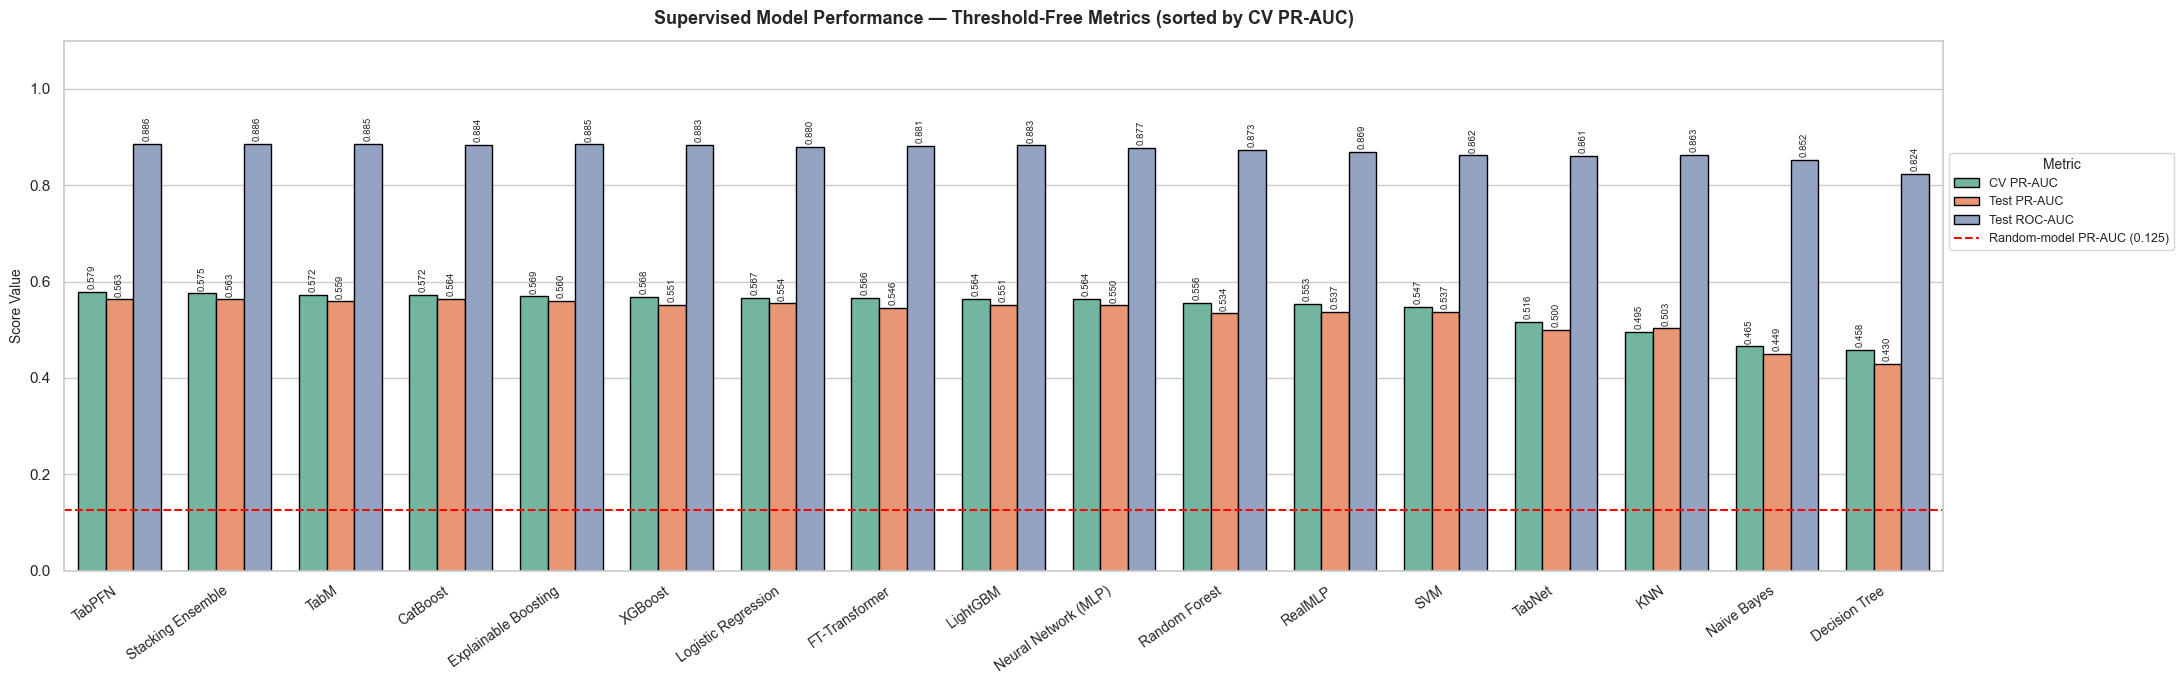

In [31]:
df_melted = df_comparison.reset_index()[['Model', 'CV PR-AUC', 'Test PR-AUC', 'Test ROC-AUC']].melt(
    id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(22, 7), dpi=100)
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='Set2', edgecolor='black', width=0.75)
ax.axhline(y_test.mean(), color='red', linestyle='--', lw=1.5, label=f'Random-model PR-AUC ({y_test.mean():.3f})')

plt.title('Supervised Model Performance — Threshold-Free Metrics (sorted by CV PR-AUC)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('')
plt.ylabel('Score Value', fontsize=10)
plt.ylim(0, 1.1)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.legend(title='Metric', loc='upper left', bbox_to_anchor=(1, 0.8), fontsize=9, title_fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=7, rotation=90)

plt.tight_layout()
save_figure("model_comparison_barchart.png")
plt.show()

* **The top ten models are statistically tied.** CV PR-AUC runs from 0.564 (MLP) to 0.579 (TabPFN), a spread of 0.015 when each model's own standard error is about 0.011. Test ROC-AUC for the same group is 0.877 to 0.886. All of them are about 4.5× better than a random model (PR-AUC 0.125).
* **TabPFN ranks first (CV 0.579, test ROC-AUC 0.886)**, followed by the Stacking Ensemble, TabM, CatBoost and the Explainable Boosting Machine. The foundation model does best with no tuning at all, but its lead over plain logistic regression (0.567) is only about one standard error.
* **Cross-validation switched SMOTE off for every model.** Synthetic minority patients never improved PR-AUC: the models rank patients just as well at the natural 12.5 % prevalence, and the decision threshold, not resampling, is the right place to handle the imbalance.
* **Weaker models:** TabNet (0.517), KNN (0.495), Naive Bayes (0.465) and the single Decision Tree (0.458) trail clearly. The signal here is mostly additive (age, symptoms, history), which a linear model or a boosted ensemble captures better than nearest neighbours or one tree.

### Confusion Matrix

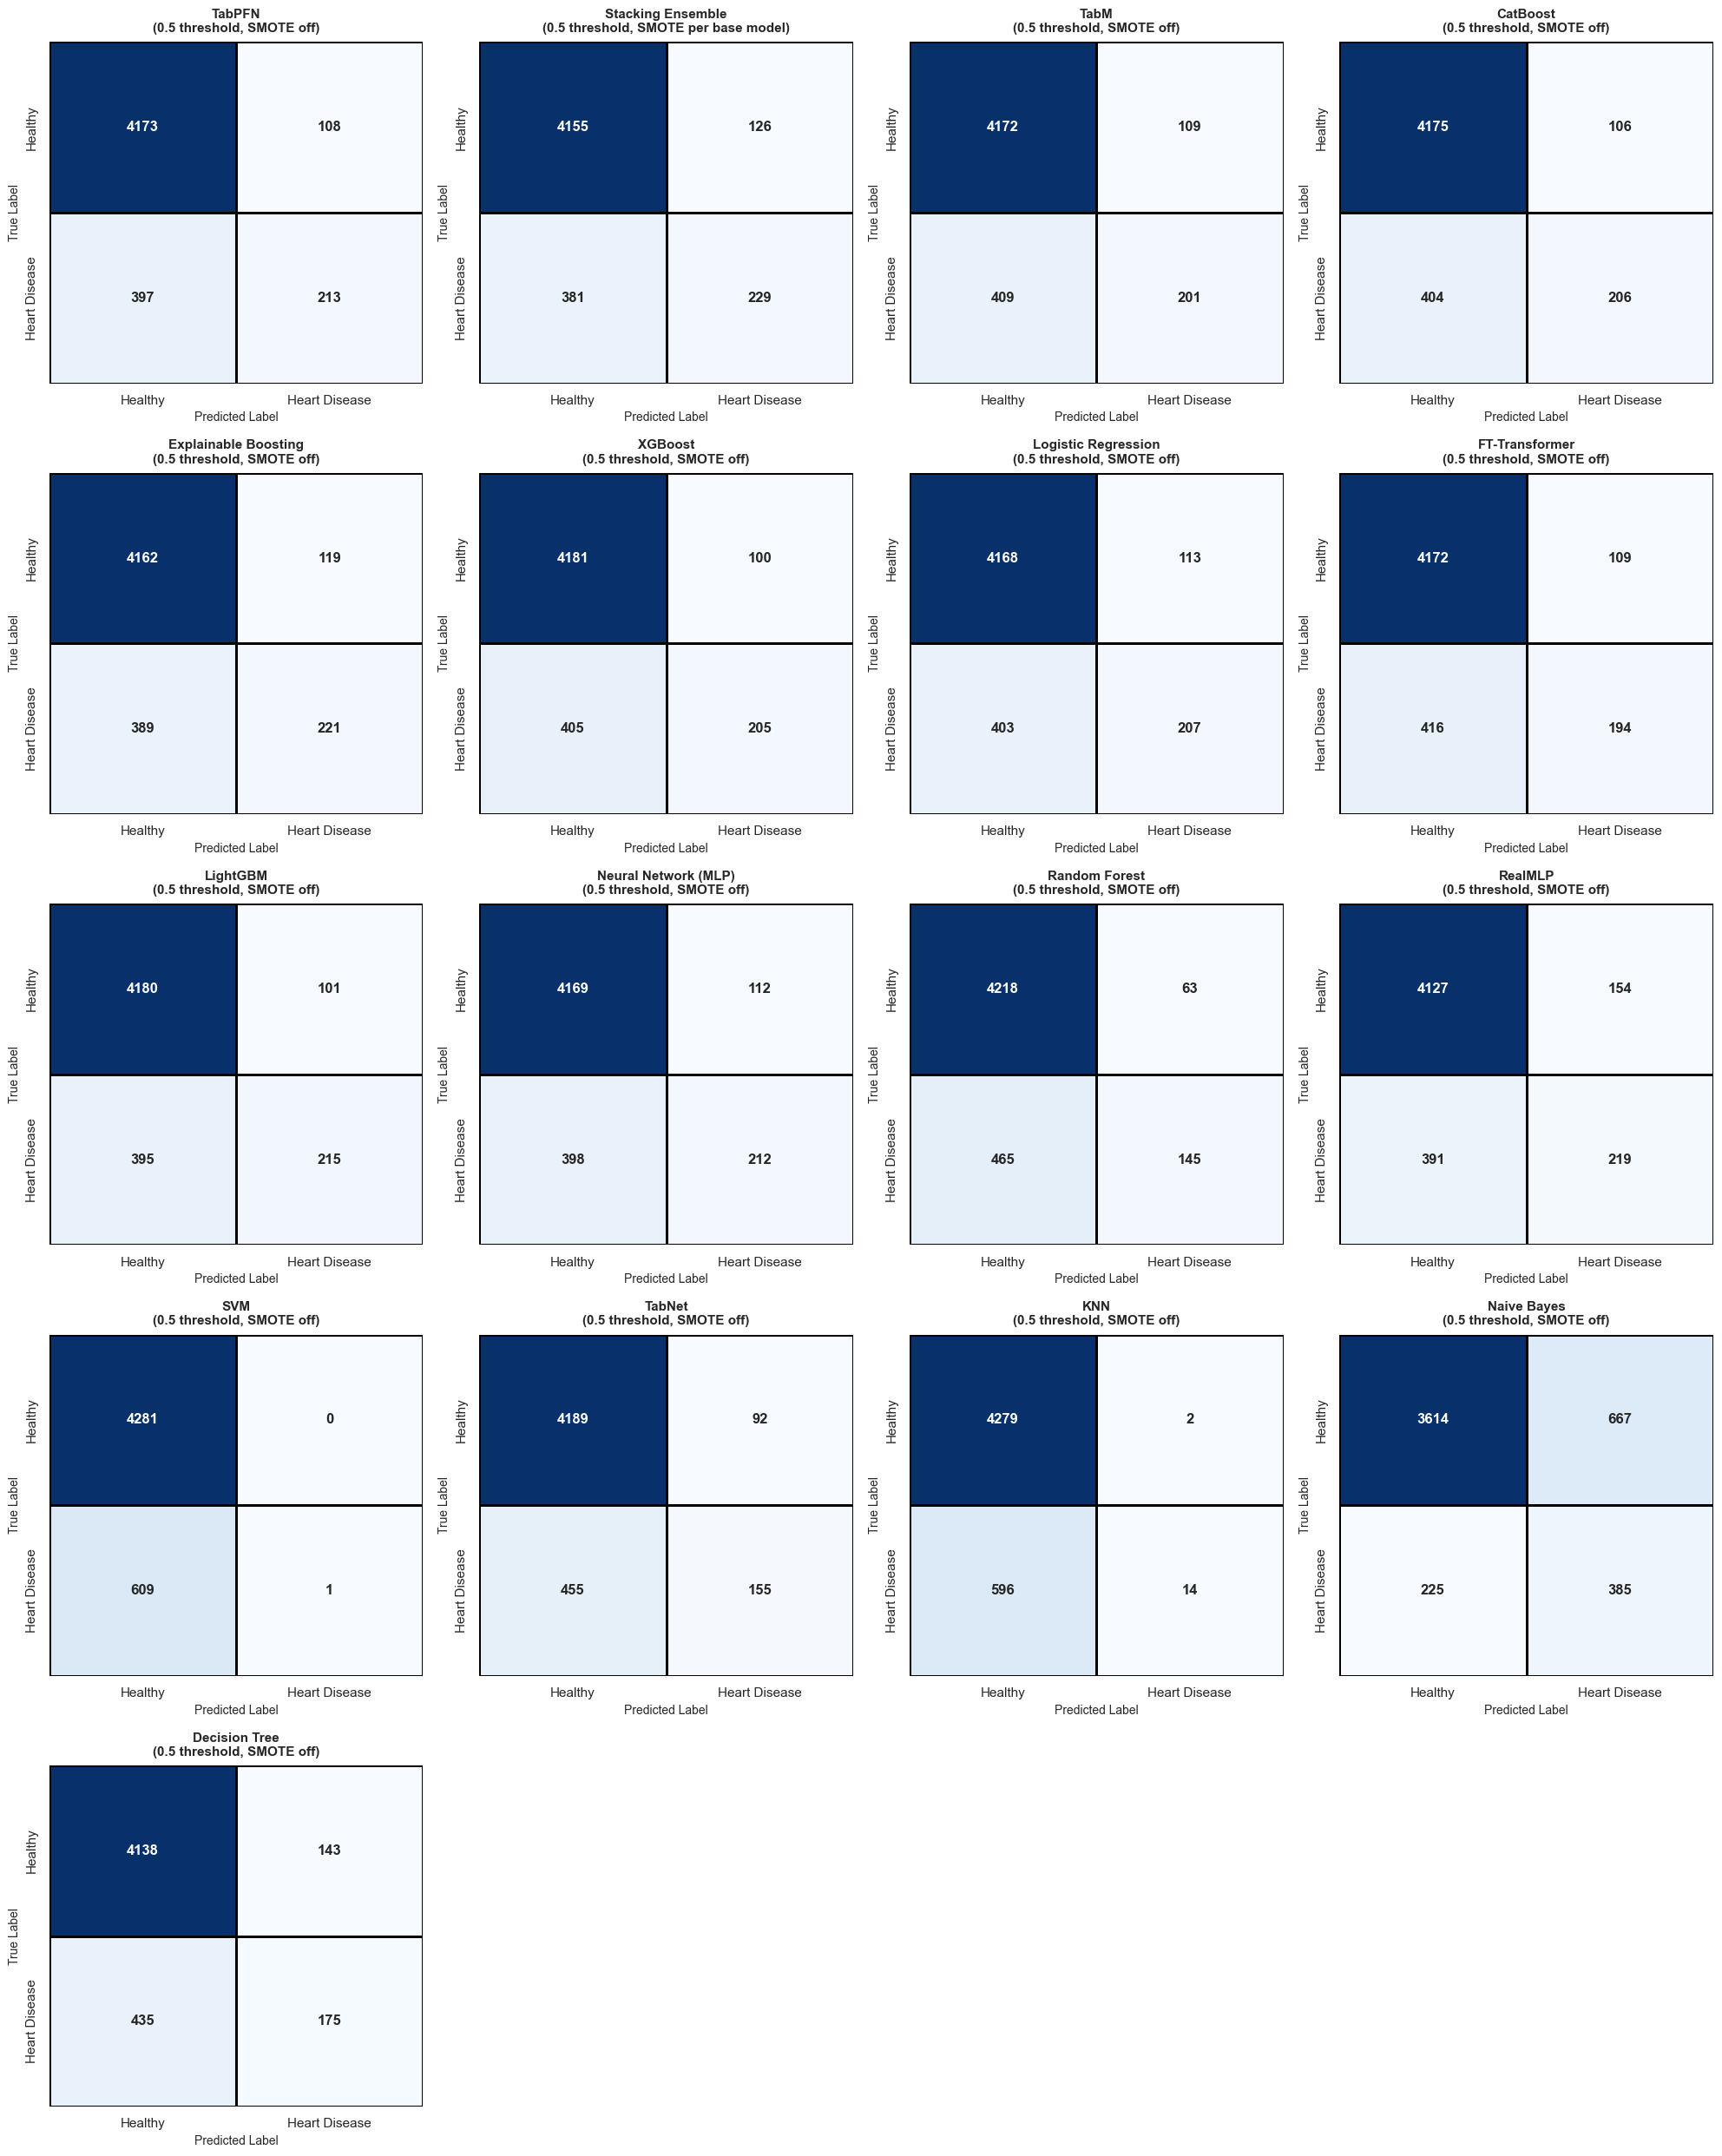

In [32]:
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

for i, name in enumerate(df_comparison.index):
    cm = confusion_matrix(y_test, fitted_models[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Healthy', 'Heart Disease'], yticklabels=['Healthy', 'Heart Disease'],
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=1, linecolor='black', ax=axes[i])
    axes[i].set_title(f"{name}\n(0.5 threshold, SMOTE {cv_summary[name]['SMOTE']})", fontsize=11, fontweight='bold', pad=8)
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

for j in range(len(df_comparison), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
save_figure("models_confusion_matrix.png")
plt.show()

* **At the default 0.5 cut-off almost every model misses most patients.** The strong models catch only 200–230 of the 610 heart disease cases (recall 33–38 %). Trained without SMOTE, their probabilities are honest and rarely exceed 0.5 at 12.5 % prevalence.
* **The extremes show why 0.5 is the wrong cut-off.** SVM flags a single patient and KNN 16, while Naive Bayes, whose probabilities are poorly calibrated, flags 1,052 and catches 385 cases at the cost of 667 false alarms.
* These matrices compare models at an arbitrary point. The clinically useful operating point is set later by the cost-based threshold.

### ROC, PR Curve

AUC (area under the curve) measures a model's ability to tell the classes apart: 0.5 is random guessing, 1.0 is perfect. For imbalanced data the PR curve is the more demanding view, because its baseline is the prevalence (0.125), not 0.5.

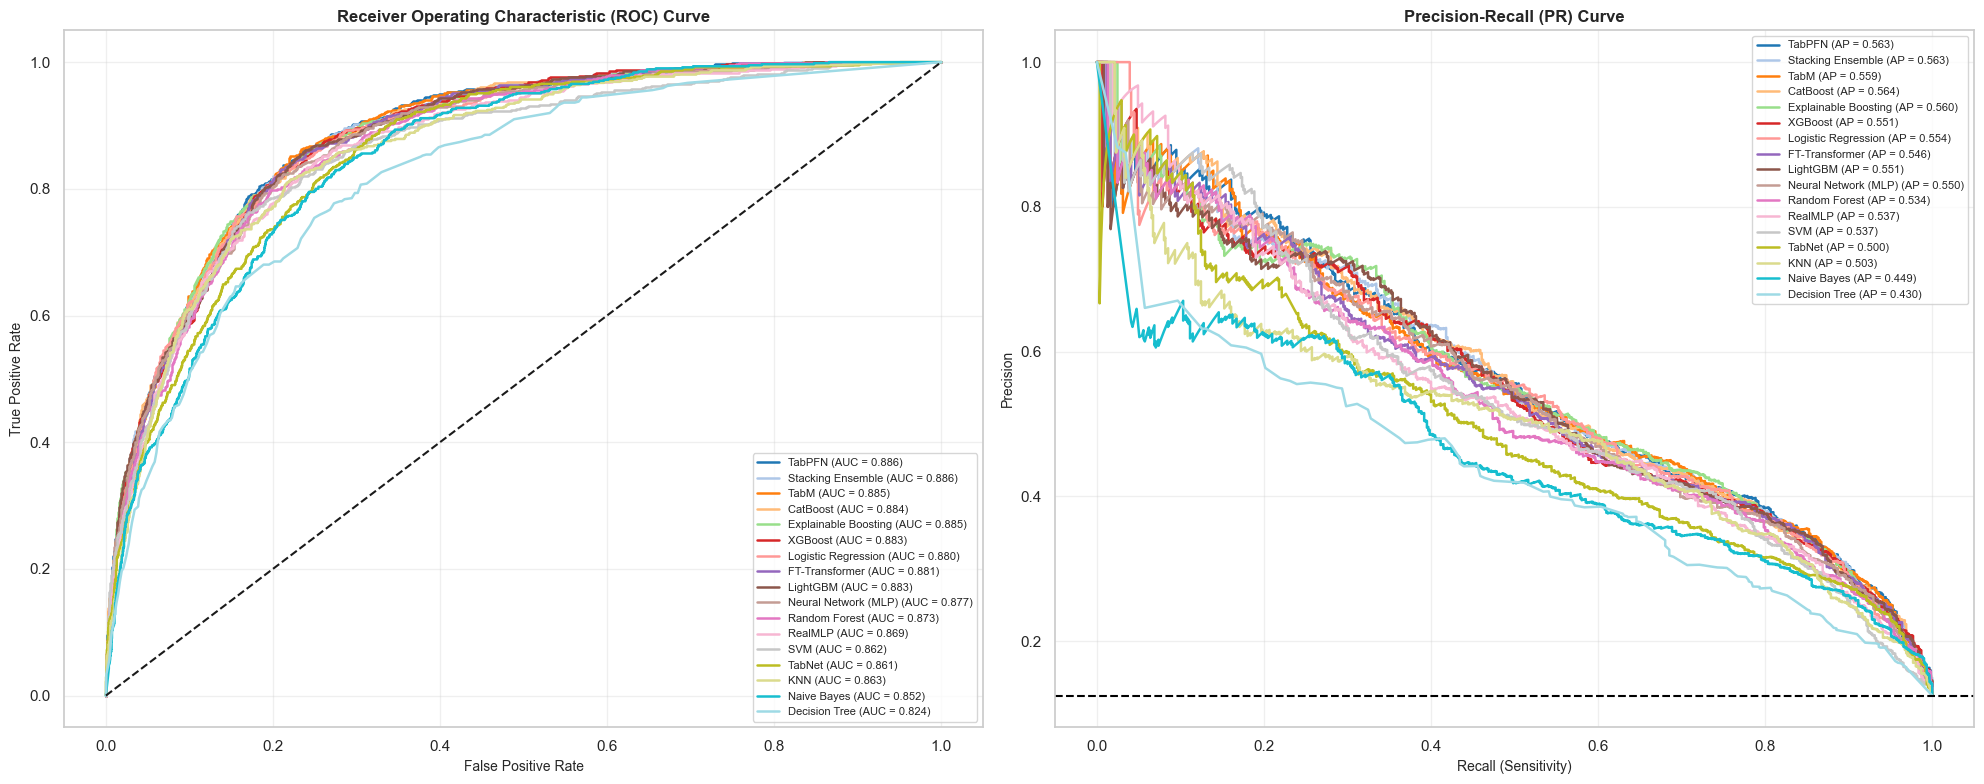

In [33]:
plt.figure(figsize=(20, 8), dpi=100)
ax_roc = plt.subplot(1, 2, 1)
ax_pr = plt.subplot(1, 2, 2)
colors = plt.cm.tab20(np.linspace(0, 1, len(df_comparison)))

for color, name in zip(colors, df_comparison.index):
    scores = test_scores[name]
    fpr, tpr, _ = roc_curve(y_test, scores)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, scores)
    ax_roc.plot(fpr, tpr, color=color, lw=1.8, label=f"{name} (AUC = {df_comparison.loc[name, 'Test ROC-AUC']:.3f})")
    ax_pr.plot(recall_vals, precision_vals, color=color, lw=1.8, label=f"{name} (AP = {df_comparison.loc[name, 'Test PR-AUC']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate', fontsize=10)
ax_roc.set_ylabel('True Positive Rate', fontsize=10)
ax_roc.legend(loc='lower right', fontsize=8)
ax_roc.grid(True, alpha=0.3)

ax_pr.axhline(y_test.mean(), color='black', linestyle='--', lw=1.5)
ax_pr.set_title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold')
ax_pr.set_xlabel('Recall (Sensitivity)', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.legend(loc='upper right', fontsize=8)
ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
save_figure("roc_pr_curve.png")
plt.show()

* **The ROC curves of the top models overlap almost completely** (AUC 0.877–0.886): they rank patients in nearly the same order. Only TabNet, KNN, Naive Bayes and the Decision Tree fall visibly below.
* **The PR curves tell the more demanding story.** Near 80 % recall, precision is roughly 35–39 %, so catching most heart disease means about 1.6 false alarms per true case. That is the realistic trade-off for a screen built from routine survey and lab data, without an ECG or imaging.

# Best Supervised Model

**Only CPU-deployable models are eligible.** The cascade runs on CPU inside the Streamlit app. The five GPU models (TabNet, FT-Transformer, RealMLP, TabM, TabPFN) stay in the benchmark above for comparison, but they can't be deployed there. TabPFN in particular keeps its whole training set inside the model and processes it again on every prediction: the calibrated model would be roughly 700 MB, and the calibration, SHAP and permutation-importance steps below would take many hours.

**Selection rule: one standard error.** Picking the single highest score over-reads noise, because the top models differ by less than their own fold-to-fold variation. Following Breiman et al. (1984) and Hastie et al. (2009), we take the best CV PR-AUC among the eligible models, subtract one standard error, and choose the **simplest** model that clears that bar. "Simplest" means most interpretable and cheapest to run: glass-box models, then tree ensembles, then neural networks and ensembles. Only training-set cross-validation is used, never the test set.

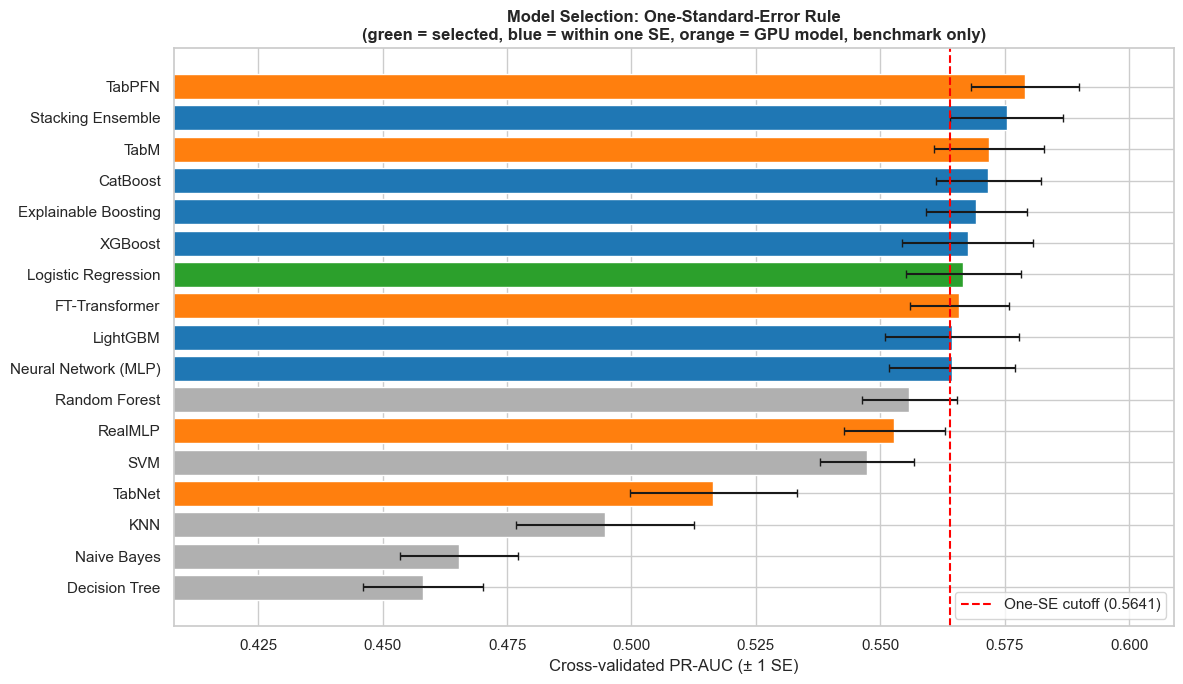

Highest CV PR-AUC overall       : TabPFN (0.5790)
Highest CV PR-AUC, deployable   : Stacking Ensemble (0.5754 ± 0.0113 SE)
One-SE cutoff                   : 0.5641
Deployable models within one SE : ['Logistic Regression', 'Explainable Boosting', 'LightGBM', 'XGBoost', 'CatBoost', 'Neural Network (MLP)', 'Stacking Ensemble']

🏆 The Best Model is: Logistic Regression
CV PR-AUC   : 0.5667 (Primary)
Test PR-AUC : 0.5545
Test ROC-AUC: 0.8802


In [34]:
# Simplest -> most complex (interpretability and deployment cost)
complexity_order = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Explainable Boosting', 'KNN', 'SVM',
                    'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost', 'Neural Network (MLP)', 'TabNet',
                    'RealMLP', 'TabM', 'FT-Transformer', 'TabPFN', 'Stacking Ensemble']

# The cascade runs on CPU: the GPU models are benchmarked above but are not eligible for deployment
deployable = [m for m in df_comparison.index if m not in GPU_MODELS]

top_model = df_comparison.loc[deployable, 'CV PR-AUC'].idxmax()
top_score, top_se = df_comparison.loc[top_model, ['CV PR-AUC', 'CV SE']]
one_se_cutoff = top_score - top_se
within_one_se = [m for m in complexity_order
                 if m in deployable and df_comparison.loc[m, 'CV PR-AUC'] >= one_se_cutoff]
best_model_name = within_one_se[0]

plt.figure(figsize=(12, 7))
ranked = df_comparison.sort_values('CV PR-AUC')
bar_colors = ['#2ca02c' if m == best_model_name else '#1f77b4' if m in within_one_se
              else '#ff7f0e' if m in GPU_MODELS else '#b0b0b0' for m in ranked.index]
plt.barh(ranked.index, ranked['CV PR-AUC'], xerr=ranked['CV SE'], color=bar_colors, capsize=3)
plt.axvline(one_se_cutoff, color='red', linestyle='--', lw=1.5, label=f'One-SE cutoff ({one_se_cutoff:.4f})')
plt.xlim(ranked['CV PR-AUC'].min() - 0.05, ranked['CV PR-AUC'].max() + 0.03)
plt.xlabel('Cross-validated PR-AUC (± 1 SE)')
plt.title('Model Selection: One-Standard-Error Rule\n(green = selected, blue = within one SE, orange = GPU model, benchmark only)', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
save_figure("model_selection_one_se.png")
plt.show()

overall_top = df_comparison['CV PR-AUC'].idxmax()
print(f"Highest CV PR-AUC overall       : {overall_top} ({df_comparison.loc[overall_top, 'CV PR-AUC']:.4f})")
print(f"Highest CV PR-AUC, deployable   : {top_model} ({top_score:.4f} ± {top_se:.4f} SE)")
print(f"One-SE cutoff                   : {one_se_cutoff:.4f}")
print(f"Deployable models within one SE : {within_one_se}")
print(f"\n🏆 The Best Model is: {best_model_name}")
print(f"CV PR-AUC   : {df_comparison.loc[best_model_name, 'CV PR-AUC']:.4f} (Primary)")
print(f"Test PR-AUC : {df_comparison.loc[best_model_name, 'Test PR-AUC']:.4f}")
print(f"Test ROC-AUC: {df_comparison.loc[best_model_name, 'Test ROC-AUC']:.4f}")

* **Logistic Regression is selected.** TabPFN has the highest CV PR-AUC overall (0.579) but is GPU-only. The best deployable model is the Stacking Ensemble (0.575 ± 0.011), so the one-SE cutoff is 0.564, and seven deployable models clear it. Logistic Regression (0.567) is the simplest of them.
* **The price of simplicity is small.** On the untouched test set the logistic regression scores PR-AUC 0.555 and ROC-AUC 0.880, against 0.563 and 0.886 for TabPFN: a 0.008 PR-AUC gap, well inside the bootstrap interval below.
* In return, every prediction is a transparent weighted sum that runs instantly on a CPU, can be audited coefficient by coefficient, and ships as a 13 MB file. The grid chose weak regularisation (C = 100, L2): with 19,563 training patients, shrinking the coefficients doesn't help.

### Model Calibration
The deployed model has to output probabilities we can say out loud ("a 30 % chance of heart disease"), and the decision threshold must be set on *those* probabilities. So calibration comes before threshold analysis. `CalibratedClassifierCV` fits isotonic regression on held-out folds of the original, un-oversampled data, which also removes any probability inflation left by SMOTE.

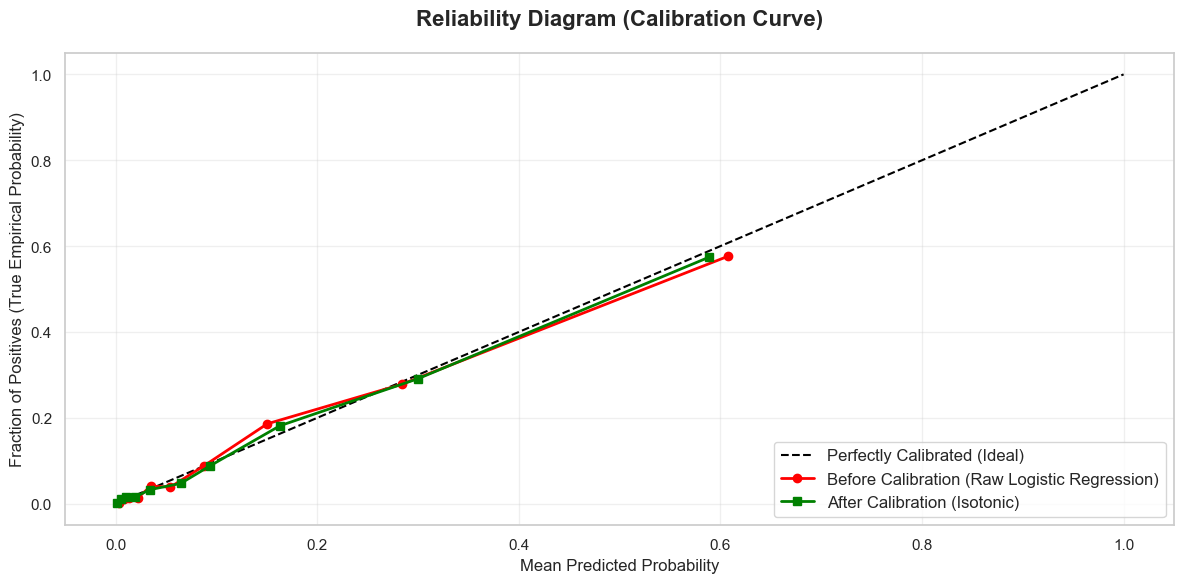

In [35]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Wrap the winning pipeline with a CalibratedClassifierCV
# cv=3 will cross-validate and retrain the model internally to avoid data leakage during calibration
winner_model = fitted_models[best_model_name]
calibrated_clf = CalibratedClassifierCV(estimator=winner_model, method='isotonic', cv=3)
calibrated_clf.fit(X_train, y_train)

raw_probas = positive_scores(winner_model, X_test)
calib_probas = calibrated_clf.predict_proba(X_test)[:, 1]
has_raw_probabilities = hasattr(winner_model, 'predict_proba')   # SVM only has a decision function

# We use strategy='quantile' since the dataset is imbalanced
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calib_probas, n_bins=10, strategy='quantile')

plt.figure(figsize=(12, 6), dpi=100)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated (Ideal)')
if has_raw_probabilities:
    prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw_probas, n_bins=10, strategy='quantile')
    plt.plot(prob_pred_raw, prob_true_raw, marker='o', color='red', lw=2, label=f'Before Calibration (Raw {best_model_name})')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', color='green', lw=2, label='After Calibration (Isotonic)')

plt.title('Reliability Diagram (Calibration Curve)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives (True Empirical Probability)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_figure("reliability_diagram.png")
plt.show()

### Threshold Analysis
The threshold is chosen on **out-of-fold predictions from the training set**: every training patient is scored by a calibrated model that never saw them. Tuning it on the test set, as the original heart notebook did, would make the reported test metrics optimistic.

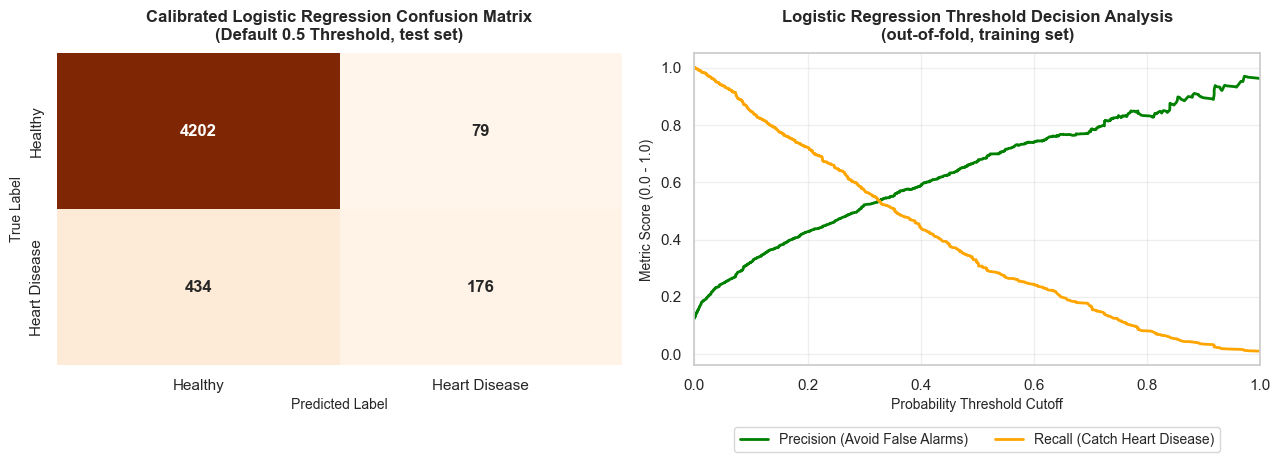


========================= OPERATIONAL CLINICAL IMPACT TABLE (test set) =========================


,Caught Heart Disease (True Positives),Missed Heart Disease (False Negatives),False Alarms (False Positives),Recall,Healthy Flagged Rate
Threshold,,,,,
0.05,568,42,1796,93.1%,42.0%
0.10,524,86,1068,85.9%,24.9%
0.15,478,132,760,78.4%,17.8%
0.20,446,164,628,73.1%,14.7%
0.30,350,260,355,57.4%,8.3%
0.50,176,434,79,28.9%,1.8%


In [36]:
oof_jobs = 1 if best_model_name in GPU_MODELS else 5
oof_probas = cross_val_predict(
    CalibratedClassifierCV(estimator=clone(winner_model), method='isotonic', cv=3),
    X_train, y_train, cv=cv_strategy, method='predict_proba', n_jobs=oof_jobs
)[:, 1]

plt.figure(figsize=(13, 5), dpi=100)

# Test-set confusion matrix at the default 0.5 threshold on calibrated probabilities
default_preds = np.where(calib_probas >= 0.5, 1, 0)
cm = confusion_matrix(y_test, default_preds)
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Healthy', 'Heart Disease'], yticklabels=['Healthy', 'Heart Disease'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'Calibrated {best_model_name} Confusion Matrix\n(Default 0.5 Threshold, test set)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

# THRESHOLD OVERLAY ANALYSIS (out-of-fold training predictions)
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probas)
plt.subplot(1, 2, 2)
plt.plot(thresholds, precisions[:-1], label='Precision (Avoid False Alarms)', color='green', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall (Catch Heart Disease)', color='orange', lw=2)
plt.title(f'{best_model_name} Threshold Decision Analysis\n(out-of-fold, training set)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Probability Threshold Cutoff', fontsize=10)
plt.ylabel('Metric Score (0.0 - 1.0)', fontsize=10)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2, fontsize=10)

plt.tight_layout()
plt.show()

# SIMULATION TABLE (test set, calibrated probabilities)
simulation_data = []
for t in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    sim_preds = np.where(calib_probas >= t, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, sim_preds).ravel()
    simulation_data.append({
        'Threshold': t,
        'Caught Heart Disease (True Positives)': tp,
        'Missed Heart Disease (False Negatives)': fn,
        'False Alarms (False Positives)': fp,
        'Recall': f"{tp / (tp + fn):.1%}",
        'Healthy Flagged Rate': f"{fp / (tn + fp):.1%}"
    })

df_sim = pd.DataFrame(simulation_data).set_index('Threshold')
print("\n========================= OPERATIONAL CLINICAL IMPACT TABLE (test set) =========================")
display(df_sim)

* **The cut-off decides who gets referred.** On the test set a 0.10 threshold catches 85.9 % of heart disease but flags 24.9 % of healthy patients; 0.20 catches 73.1 % and flags 14.7 %; the default 0.50 catches only 28.9 %.
* Below about 0.3 the model favours recall over precision, which is what a first-line screening step needs.
* No threshold catches everyone without flagging many healthy people: at 0.05, 93 % recall costs a referral for 42 % of healthy patients. Some patients with heart disease look clinically ordinary in this data, for example treated patients whose readings are now normal.

### Automated Cost-Based Threshold Optimization

A missed heart disease case (False Negative) is penalised 5 and an unnecessary cardiology referral (False Positive) 1, the same 5:1 ratio as the original heart notebook and the kidney and lung modules. Here the cost is summed over **patient counts** (5·FN + 1·FP), which is the actual clinical cost. For perfectly calibrated probabilities, decision theory puts the optimum at *p* = 1 / (1 + 5) ≈ 0.167, a useful cross-check on the empirical result.

Automatically determined optimal threshold (out-of-fold, training set): 0.2003
Bayes-optimal threshold for perfectly calibrated probabilities:           0.1667

=== Metrics at Optimal Threshold (test set) ===
Recall (Sensitivity) : 0.7311
Precision            : 0.4157
F1-Score             : 0.5300
Specificity          : 0.8535


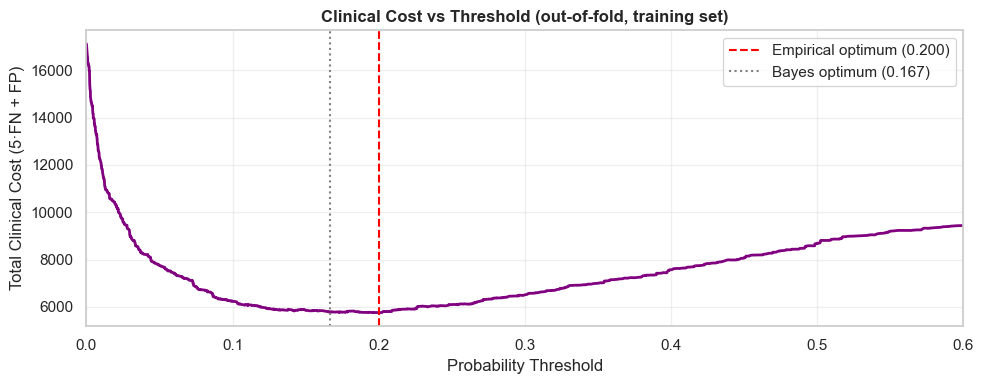

In [37]:
FN_COST, FP_COST = 5, 1

candidate_thresholds = np.unique(oof_probas)
positives = (y_train.values == 1)
total_cost = np.array([FN_COST * np.sum(positives & (oof_probas < t)) + FP_COST * np.sum(~positives & (oof_probas >= t))
                       for t in candidate_thresholds])

best_threshold = float(candidate_thresholds[np.argmin(total_cost)])
bayes_threshold = FP_COST / (FP_COST + FN_COST)

print(f"Automatically determined optimal threshold (out-of-fold, training set): {best_threshold:.4f}")
print(f"Bayes-optimal threshold for perfectly calibrated probabilities:           {bayes_threshold:.4f}\n")

# Apply the training-set threshold to the untouched test set
sim_preds_best = np.where(calib_probas >= best_threshold, 1, 0)

print("=== Metrics at Optimal Threshold (test set) ===")
print(f"Recall (Sensitivity) : {recall_score(y_test, sim_preds_best):.4f}")
print(f"Precision            : {precision_score(y_test, sim_preds_best):.4f}")
print(f"F1-Score             : {f1_score(y_test, sim_preds_best):.4f}")
tn, fp, fn, tp = confusion_matrix(y_test, sim_preds_best).ravel()
print(f"Specificity          : {tn / (tn + fp):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(candidate_thresholds, total_cost, color='purple', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Empirical optimum ({best_threshold:.3f})')
plt.axvline(bayes_threshold, color='gray', linestyle=':', label=f'Bayes optimum ({bayes_threshold:.3f})')
plt.xlim(0, 0.6)
plt.xlabel('Probability Threshold')
plt.ylabel('Total Clinical Cost (5·FN + FP)')
plt.title('Clinical Cost vs Threshold (out-of-fold, training set)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Best Threshold In Confusion Matrix

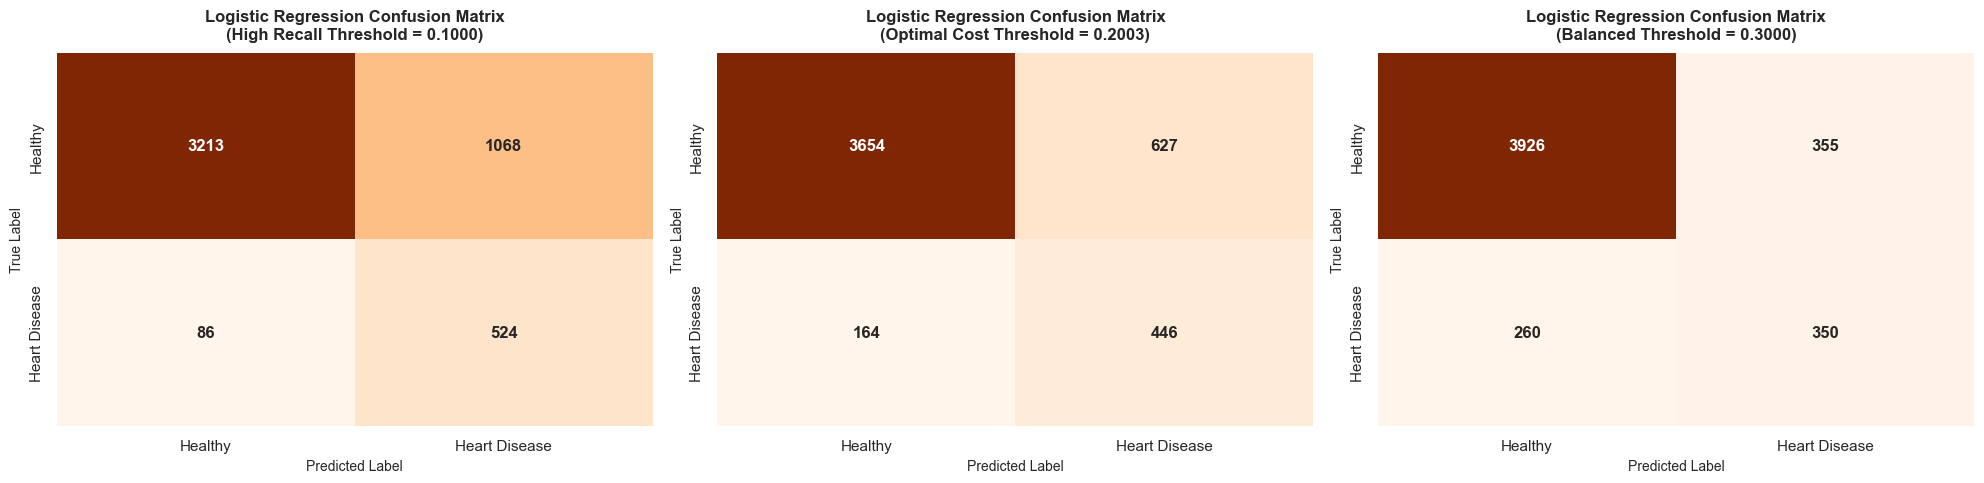

In [38]:
# Visualize Confusion Matrices for the top selected operational thresholds
plt.figure(figsize=(20, 5), dpi=100)
operating_points = [(0.10, 'High Recall Threshold'), (best_threshold, 'Optimal Cost Threshold'), (0.30, 'Balanced Threshold')]

for i, (t, label) in enumerate(operating_points, start=1):
    cm_t = confusion_matrix(y_test, np.where(calib_probas >= t, 1, 0))
    plt.subplot(1, 3, i)
    sns.heatmap(cm_t, annot=True, fmt='d', cmap='Oranges', cbar=False,
                xticklabels=['Healthy', 'Heart Disease'], yticklabels=['Healthy', 'Heart Disease'],
                annot_kws={'size': 12, 'weight': 'bold'})
    plt.title(f'{best_model_name} Confusion Matrix\n({label} = {t:.4f})', fontsize=12, fontweight='bold', pad=10)
    plt.xlabel('Predicted Label', fontsize=10)
    plt.ylabel('True Label', fontsize=10)

plt.tight_layout()
save_figure("optimal_threshold_confusion_matrix.png")
plt.show()

In [39]:
def operating_metrics(label, probas, threshold):
    preds = np.where(probas >= threshold, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    return {'Model': label, 'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds, zero_division=0),
            'Recall': recall_score(y_test, preds, zero_division=0),
            'F1-Score': f1_score(y_test, preds, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, probas), 'PR-AUC (AP)': average_precision_score(y_test, probas),
            'Missed Patients (FN)': int(fn), 'False Alarms (FP)': int(fp)}

calibration_rows = [operating_metrics(f'Calibrated {best_model_name} @ 0.5', calib_probas, 0.5),
                    operating_metrics(f'Calibrated {best_model_name} @ {best_threshold:.3f} (optimal)', calib_probas, best_threshold)]
if has_raw_probabilities:
    calibration_rows.insert(0, operating_metrics(f'Raw {best_model_name} @ 0.5', raw_probas, 0.5))
df_calib_comp = pd.DataFrame(calibration_rows).set_index('Model')

print("================================ CALIBRATION PERFORMANCE COMPARISON ================================")
display(df_calib_comp.style.background_gradient(
    cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC (AP)']
).background_gradient(
    cmap='Reds', subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC (AP)': '{:.4f}',
    'Missed Patients (FN)': '{:,.0f}', 'False Alarms (FP)': '{:,.0f}'
}))

================================ CALIBRATION PERFORMANCE COMPARISON ================================


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC (AP),Missed Patients (FN),False Alarms (FP)
Model,,,,,,,,
Raw Logistic Regression @ 0.5,0.8945,0.6469,0.3393,0.4452,0.8802,0.5545,403,113
Calibrated Logistic Regression @ 0.5,0.8951,0.6902,0.2885,0.4069,0.8803,0.5541,434,79
Calibrated Logistic Regression @ 0.200 (optimal),0.8383,0.4157,0.7311,0.5300,0.8803,0.5541,164,627


* **The threshold, not calibration, changes the clinical outcome.** At 0.5 the calibrated model misses 434 of 610 heart disease patients (recall 28.9 %). At the cost-optimal 0.200 it misses 164 (recall 73.1 %): **270 more patients caught** for 548 extra referrals of healthy people, precisely the 5:1 trade the cost function was built to accept.
* **Ranking is unchanged by calibration** (ROC-AUC 0.880, PR-AUC 0.554 before and after), as expected from a monotone re-mapping. The raw model's probabilities were already close to the diagonal because it was trained without SMOTE.
* **The optimal threshold (0.200) sits close to the decision-theory value of 0.167**, a sign that the calibrated probabilities are behaving as real probabilities.

### Bootstrapped Confidence Intervals (Model Reliability)

In medical literature, point estimates (like Recall = 0.80) are rarely reported alone. Because the test set is one sample of the population, we need to know how much each metric would move on another sample of patients.

Bootstrapping (resampling the test set with replacement) simulates 1,000 test sets and evaluates the calibrated model at the optimal threshold on each. The 2.5th–97.5th percentiles give the 95 % confidence interval for each metric.

In [40]:
from sklearn.utils import resample

n_iterations = 1000
n_size = len(X_test)
y_test_array = y_test.values
test_preds = sim_preds_best

bootstrapped = {'Recall': [], 'Precision': [], 'ROC-AUC': [], 'PR-AUC': []}

for i in range(n_iterations):
    # Resample the indices with replacement
    indices = resample(np.arange(n_size), replace=True, n_samples=n_size, random_state=i)
    y_true_boot, y_pred_boot, y_proba_boot = y_test_array[indices], test_preds[indices], calib_probas[indices]

    # Ensure the bootstrap sample contains both classes to calculate AUCs safely
    if len(np.unique(y_true_boot)) < 2:
        continue

    bootstrapped['Recall'].append(recall_score(y_true_boot, y_pred_boot, zero_division=0))
    bootstrapped['Precision'].append(precision_score(y_true_boot, y_pred_boot, zero_division=0))
    bootstrapped['ROC-AUC'].append(roc_auc_score(y_true_boot, y_proba_boot))
    bootstrapped['PR-AUC'].append(average_precision_score(y_true_boot, y_proba_boot))

def calc_ci(metrics_list, alpha=0.95):
    lower_bound = np.percentile(metrics_list, (1 - alpha) / 2 * 100)
    upper_bound = np.percentile(metrics_list, (1 + alpha) / 2 * 100)
    return np.mean(metrics_list), lower_bound, upper_bound

confidence_intervals = {}
print(f"=== 95% Bootstrapped Confidence Intervals ({n_iterations} Iterations, threshold {best_threshold:.3f}) ===")
for metric, values in bootstrapped.items():
    mean_val, lower_val, upper_val = calc_ci(values)
    confidence_intervals[metric] = {'mean': mean_val, 'ci_lower': lower_val, 'ci_upper': upper_val}
    print(f"{metric:9s} : {mean_val:.3f} (95% CI: {lower_val:.3f} - {upper_val:.3f})")

=== 95% Bootstrapped Confidence Intervals (1000 Iterations, threshold 0.200) ===
Recall    : 0.732 (95% CI: 0.696 - 0.767)
Precision : 0.416 (95% CI: 0.386 - 0.446)
ROC-AUC   : 0.880 (95% CI: 0.866 - 0.893)
PR-AUC    : 0.555 (95% CI: 0.515 - 0.597)


* **Recall 0.732 (95 % CI 0.696–0.767).** On a comparable group of patients the calibrated model at the 0.200 threshold should catch about 70–77 % of heart disease cases. The lower bound, 69.6 %, is the worst case to plan around.
* **Precision 0.416 (0.386–0.446).** About 4 in 10 referrals are true cases, reasonable at 12.5 % prevalence for a first-line screen before an ECG or stress test.
* **ROC-AUC 0.880 (0.866–0.893) and PR-AUC 0.555 (0.515–0.597).** The intervals are narrow because the test set has 4,891 patients. With the old 184-patient UCI test set they were several times wider.

### Brier Score

The Brier score is the mean squared difference between the predicted probability and the actual outcome (0 or 1). Lower is better: it measures calibration and sharpness together. At 12.5 % prevalence, always predicting 0.125 scores ≈ 0.109, which is the bar to beat.

In [41]:
from sklearn.metrics import brier_score_loss

brier_reference = brier_score_loss(y_test, np.full(len(y_test), y_train.mean()))
brier_calibrated = brier_score_loss(y_test, calib_probas)
print(f"Brier Score (Always predict prevalence): {brier_reference:.4f}")
if has_raw_probabilities:
    brier_raw = brier_score_loss(y_test, raw_probas)
    print(f"Brier Score (Raw {best_model_name}): {brier_raw:.4f}")
print(f"Brier Score (Calibrated {best_model_name}): {brier_calibrated:.4f}")

if has_raw_probabilities and brier_calibrated < brier_raw:
    print("\nInterpretation: The calibrated model has a lower Brier Score, indicating better calibration (its predicted probabilities are closer to the true probabilities).")
elif has_raw_probabilities and brier_calibrated > brier_raw:
    print("\nInterpretation: The raw model has a lower Brier Score; its probabilities were already well calibrated, and isotonic regression mainly adds a little variance.")

Brier Score (Always predict prevalence): 0.1092
Brier Score (Raw Logistic Regression): 0.0772
Brier Score (Calibrated Logistic Regression): 0.0767

Interpretation: The calibrated model has a lower Brier Score, indicating better calibration (its predicted probabilities are closer to the true probabilities).


* **The probabilities are trustworthy.** Brier score 0.0767 after calibration, against 0.1092 for always predicting the prevalence, a 30 % improvement.
* Calibration barely changes it (raw 0.0772). A logistic regression trained without SMOTE already outputs well-calibrated probabilities, as the reliability diagram shows; the isotonic step is kept as a safeguard.
* A predicted 30 % therefore means roughly 3 in 10 such patients have diagnosed heart disease, which is what a clinician needs when explaining risk.

# Feature Importance

### SHAP

To understand what drives the predictions we use SHAP (SHapley Additive exPlanations). The explainer matches the model type: exact `TreeExplainer` for tree ensembles, `LinearExplainer` for logistic regression, and a model-agnostic permutation explainer otherwise. The permutation explainer calls the model thousands of times per patient, so for models that are slow to predict (TabPFN and the other GPU models, KNN, SVM) it uses a 25-patient background and a single forward + backward pass over the features, about 3,800 predictions per patient instead of 50,000. Values are in log-odds for tree and linear models and in probability for the model-agnostic explainer, always for the base model before calibration. Isotonic calibration is a monotone re-mapping, so it doesn't change which features push a patient up or down.

**Plots are grouped by clinical input.** Pulse pressure is exactly systolic − diastolic, and non-HDL cholesterol is exactly total − HDL, so a model can split one blood-pressure effect into large opposite-signed parts that cancel out. SHAP values add up, so they are summed per clinical input: *blood pressure* (systolic, diastolic, pulse pressure), *cholesterol* (total, HDL, non-HDL, ratio) and each categorical answer's one-hot columns. Colour shows systolic pressure for blood pressure, non-HDL for cholesterol, and categories ranked from lowest to highest risk.

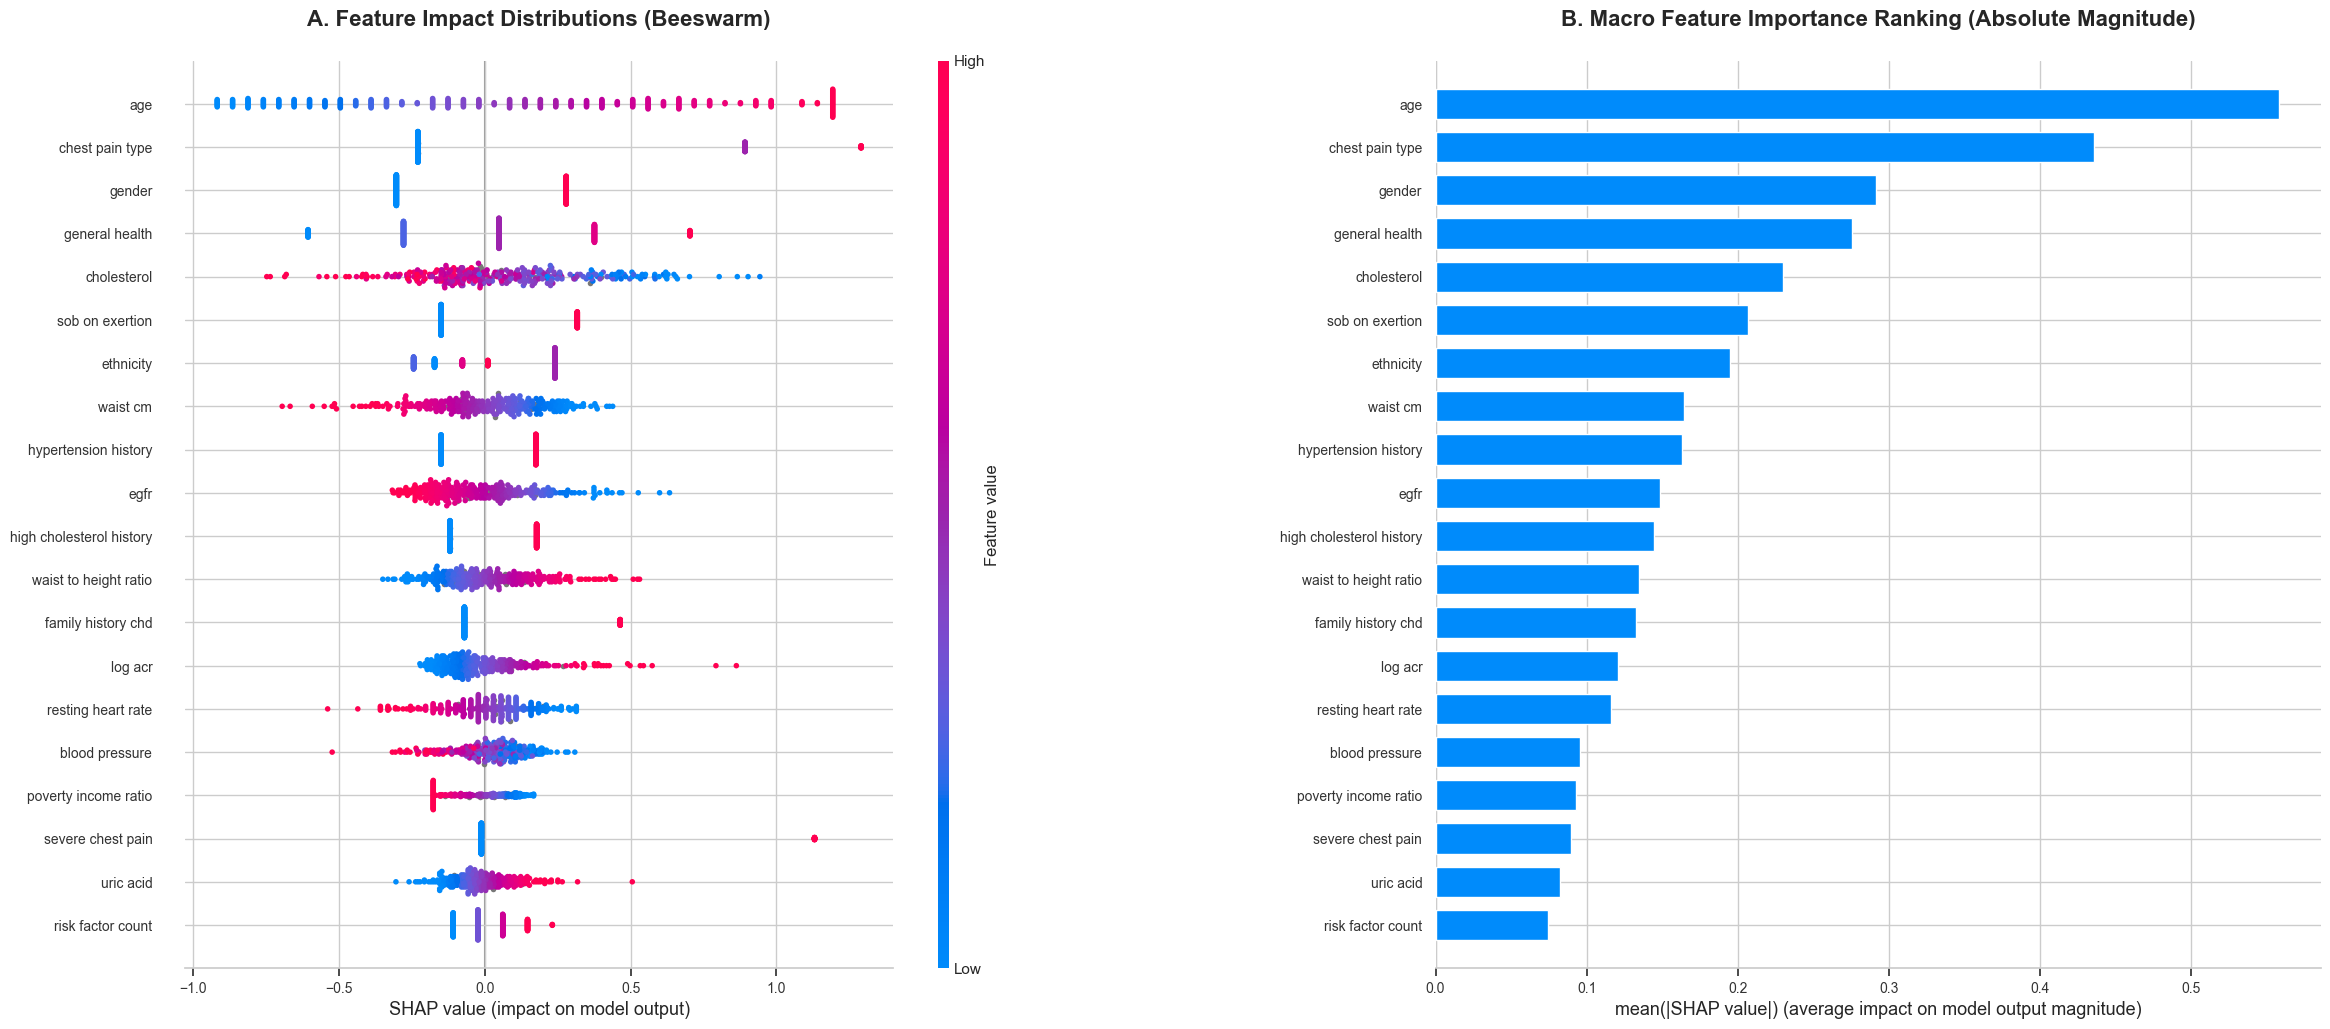

In [42]:
import shap
import matplotlib.gridspec as gridspec

# Stacking has no single classifier step; in that case explain the best single deployable pipeline
pipeline_models = [m for m in df_comparison.index if m in deployable and hasattr(fitted_models[m], 'named_steps')]
explain_name = best_model_name if best_model_name in pipeline_models else pipeline_models[0]
if explain_name != best_model_name:
    print(f"{best_model_name} has no single classifier step; SHAP explains {explain_name} instead.")

# Extract the best pipeline and its components
best_pipeline = fitted_models[explain_name]
model_object = best_pipeline.named_steps['classifier']
preprocessor = best_pipeline[:-1]           # engineering -> imputation -> (SMOTENC skipped at transform) -> encoding

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = list(best_pipeline.named_steps['encoding'].get_feature_names_out())

tree_models = (XGBClassifier, LGBMClassifier, CatBoostClassifier, RandomForestClassifier, DecisionTreeClassifier)
fast_explainer = isinstance(model_object, tree_models + (LogisticRegression,))

# Permutation SHAP needs thousands of predictions per patient. These models are slow to predict: GPU forward passes,
# TabPFN re-reading its whole training set, KNN / SVM comparing each patient against the training data
slow_to_predict = explain_name in GPU_MODELS | {'KNN', 'SVM'}

def build_shap_explainer(model, background):
    if isinstance(model, tree_models):
        return shap.TreeExplainer(model)
    if isinstance(model, LogisticRegression):
        return shap.LinearExplainer(model, background)
    masker = shap.maskers.Independent(background, max_samples=len(background))
    return shap.Explainer(lambda data: positive_scores(model, data), masker, feature_names=feature_names)

def compute_shap_values(explainer, data):
    # For slow models: one forward + backward permutation pass per patient (2M + 1 evaluations), the minimum for exact efficiency
    if slow_to_predict and isinstance(explainer, shap.explainers.PermutationExplainer):
        return explainer(data, max_evals=2 * data.shape[1] + 1)
    return explainer(data)

background = shap.sample(X_train_processed, 25 if slow_to_predict else 100, random_state=RANDOM_STATE)
explainer = build_shap_explainer(model_object, background)

# Extract a sample array for SHAP (the model-agnostic explainer is ~100x slower, so it gets fewer rows)
n_explain = 300 if fast_explainer else (50 if slow_to_predict else 100)
X_sample = X_test_processed[:n_explain]
shap_values = compute_shap_values(explainer, X_sample)
if len(shap_values.values.shape) == 3:          # (samples, features, classes) -> heart disease class
    shap_values = shap_values[..., 1]
shap_values.feature_names = feature_names

# Pulse pressure (systolic - diastolic) and non-HDL cholesterol (total - HDL) are exact combinations of raw columns, so a
# model can split one effect into large opposite-signed parts. SHAP values add up, so they are summed per clinical input:
# the blood-pressure and cholesterol families, and the one-hot columns of each categorical answer
feature_groups = {'blood_pressure': ['systolic_bp', 'diastolic_bp', 'pulse_pressure'],
                  'cholesterol': ['total_cholesterol', 'hdl_cholesterol', 'non_hdl_cholesterol', 'tc_hdl_ratio']}
category_order = {'chest_pain_type': ['No pain', 'Non-exertional', 'Exertional'],
                  'diabetes_status': ['No', 'Borderline', 'Yes'], 'smoking_status': ['Never', 'Former', 'Current']}

def source_column(feature):
    for group, members in feature_groups.items():
        if feature in members:
            return group
    for column in categorical_features:
        if feature.startswith(column + '_'):
            return column
    return feature

def group_shap(values):
    # (patients x encoded features) -> (patients x clinical inputs)
    return pd.DataFrame(values, columns=feature_names).T.groupby(source_column).sum().T

def group_colour_values(raw):
    # Value that colours each clinical input in the beeswarm (categories ranked from lowest to highest risk)
    colours = {}
    for column in grouped_shap.columns:
        if column == 'blood_pressure':
            colours[column] = raw['systolic_bp']
        elif column == 'cholesterol':
            colours[column] = raw['non_hdl_cholesterol']
        elif column in categorical_features:
            order = category_order.get(column, sorted(raw[column].dropna().unique()))
            colours[column] = raw[column].map({category: rank for rank, category in enumerate(order)})
        else:
            colours[column] = raw[column]
    return pd.DataFrame(colours).astype(float)

grouped_shap = group_shap(shap_values.values)
grouped_data = group_colour_values(add_custom_features(X_test.iloc[:n_explain]).reset_index(drop=True))
group_labels = [c.replace('_', ' ') for c in grouped_shap.columns]

fig = plt.figure(figsize=(24, 10), dpi=100)
gs = gridspec.GridSpec(1, 21)
ax1 = plt.subplot(gs[0, 0:9])
ax2 = plt.subplot(gs[0, 12:21])

# --- LEFT PLOT: Feature Impact Distributions (Beeswarm) ---
plt.sca(ax1)
shap.summary_plot(grouped_shap.values, grouped_data.values, feature_names=group_labels, max_display=20, show=False, plot_size=None)
ax1.set_title('A. Feature Impact Distributions (Beeswarm)', fontsize=16, fontweight='bold', pad=25)
ax1.tick_params(axis='both', labelsize=10)

# --- RIGHT PLOT: Average Absolute SHAP Value (Global Bar) ---
plt.sca(ax2)
shap.summary_plot(grouped_shap.values, grouped_data.values, plot_type="bar", feature_names=group_labels, max_display=20, show=False, plot_size=None)
ax2.set_title('B. Macro Feature Importance Ranking (Absolute Magnitude)', fontsize=16, fontweight='bold', pad=25)
ax2.tick_params(axis='both', labelsize=10)

save_figure("shap_analysis_macro_feature_importance.png")
plt.show()

* **Age dominates**, with a smooth effect: every older patient is pushed up and every younger patient down.
* **Symptoms and sex follow.** Exertional chest pain carries the largest single push (+1.3 log-odds), non-exertional pain less (+0.9), and a severe 30-minute chest-pain episode adds about +1.1 for the few patients who report it. Men sit higher than women, matching the well-known sex gap in coronary disease.
* **Self-rated health, breathlessness, hypertension, high-cholesterol and family history** each add a clear, one-directional push, as clinical guidelines would predict.
* **Kidney markers behave as expected:** low eGFR and high urine albumin (log ACR) raise risk.
* **Treatment effects are visible and must be read carefully.** High measured cholesterol and high blood pressure push *down*, because patients already diagnosed with heart disease are usually on statins and blood-pressure drugs (see the correlation analysis). The model uses this correctly to recognise *diagnosed* disease, but these two inputs should not be read as protective risk factors.
* Waist (downward) and waist-to-height ratio (upward) partly cancel: they are strongly correlated, so read them together as one central-obesity signal.

### Permutation Importance

Global, model-agnostic importance. The **raw input columns** are shuffled one at a time and pushed through the full calibrated pipeline, so shuffling `total_cholesterol` also scrambles the `non_hdl_cholesterol` and `tc_hdl_ratio` built from it. The score drop is measured in PR-AUC.

--- Permutation Importance (drop in test PR-AUC when the column is shuffled) ---


,Feature,Importance_Mean,Importance_Std
0,age,0.120079,0.006726
28,chest_pain_type,0.086751,0.008374
29,severe_chest_pain,0.028009,0.004566
11,total_cholesterol,0.025229,0.003453
27,general_health,0.022896,0.004224
16,albumin_creatinine_ratio,0.014074,0.002173
1,gender,0.013003,0.002759
23,high_cholesterol_history,0.010695,0.002013
22,hypertension_history,0.010018,0.002875
25,stroke_history,0.009211,0.002139


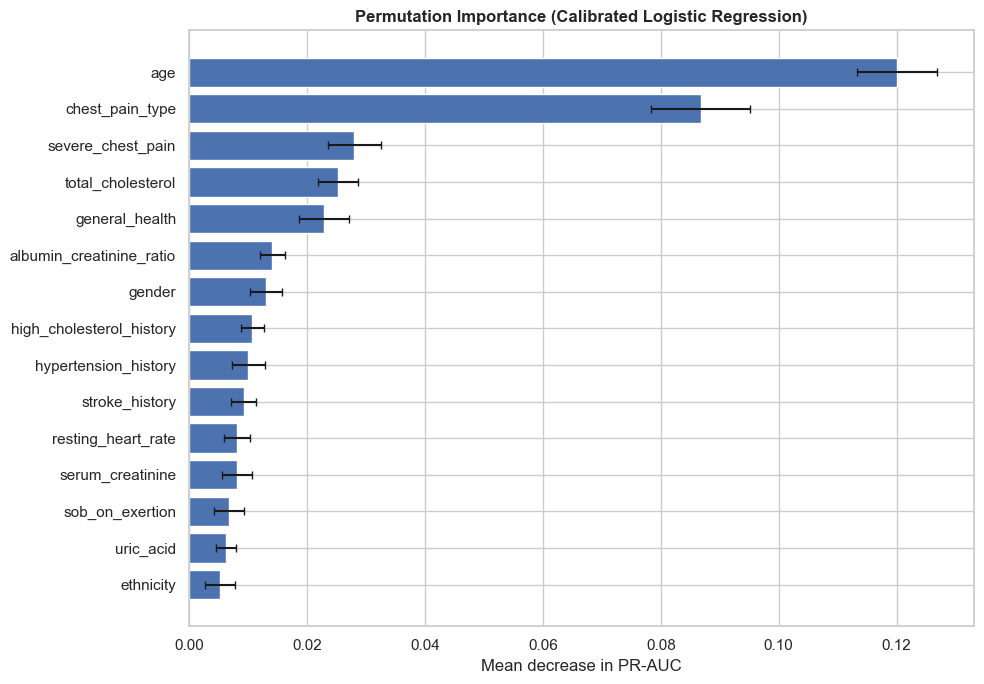

In [43]:
from sklearn.inspection import permutation_importance

perm_repeats = 3 if best_model_name in GPU_MODELS else 10
perm_jobs = 1 if best_model_name in GPU_MODELS else N_JOBS
result = permutation_importance(
    calibrated_clf, X_test, y_test, scoring='average_precision',
    n_repeats=perm_repeats, random_state=RANDOM_STATE, n_jobs=perm_jobs
)

# Format the results into a clean DataFrame
df_perm_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)
df_perm_importance.to_csv(os.path.join(results_dir, 'permutational_feature_importance.csv'), index=False)

print("--- Permutation Importance (drop in test PR-AUC when the column is shuffled) ---")
display(df_perm_importance.head(10))

plt.figure(figsize=(10, 7))
top_perm = df_perm_importance.head(15).iloc[::-1]
plt.barh(top_perm['Feature'], top_perm['Importance_Mean'], xerr=top_perm['Importance_Std'], color='#4c72b0', capsize=3)
plt.xlabel('Mean decrease in PR-AUC')
plt.title(f'Permutation Importance (Calibrated {best_model_name})', fontweight='bold')
plt.tight_layout()
save_figure("permutation_importance.png")
plt.show()

* **Age is by far the most relied-on input** (PR-AUC drops 0.120 when it is shuffled); prevalence rises about 7× from the 40s to the 70s.
* **Symptoms come next: chest-pain type (0.087) and severe chest pain lasting 30+ minutes (0.028).** The Rose questionnaire carries much of the diagnostic signal, just as chest-pain type and exercise angina did in the UCI data.
* **Then total cholesterol (0.025), general health (0.023), urine albumin (0.014) and sex (0.013),** followed by high-cholesterol, hypertension and stroke history. Total cholesterol matters through the statin effect seen in the correlation analysis: a *low* measured value in someone told their cholesterol is high signals treatment.
* All of the top ten match established cardiology knowledge; the model is not relying on noise or survey artefacts.

# Unsupervised Learning

### Dimensionality Reduction (PCA & t-SNE)

First, we prepare the data and reduce its dimensions to see whether patients group naturally before any clustering. We use the numeric features after feature engineering, **scaled before KNN imputation** (the same order as the supervised pipeline). t-SNE, DBSCAN and the silhouette scores are O(n²), so they run on a stratified sample of 6,000 patients. PCA, GMM, K-Means and the anomaly detectors use everyone.

In [44]:
X_unsup = add_custom_features(heart_data)[numerical_features]
scaler_unsup = StandardScaler()
imputer_unsup = KNNImputer(n_neighbors=5)
X_unsup_scaled = imputer_unsup.fit_transform(scaler_unsup.fit_transform(X_unsup))
labels_all = heart_data['heart_disease'].map({0: 'Healthy', 1: 'Heart Disease'}).values

# Stratified sample for the O(n^2) methods and for readable scatter plots
sample_size = min(6000, int(0.8 * len(X_unsup_scaled)))
sample_idx, _ = train_test_split(np.arange(len(X_unsup_scaled)), train_size=sample_size,
                                 stratify=heart_data['heart_disease'], random_state=RANDOM_STATE)
X_sample_unsup = X_unsup_scaled[sample_idx]
print(f"Unsupervised matrix: {X_unsup_scaled.shape} | sample for O(n^2) methods: {X_sample_unsup.shape}")

Unsupervised matrix: (24454, 25) | sample for O(n^2) methods: (6000, 25)


* **PCA (Principal Component Analysis):** Reduces the clinical features (age, blood pressure, cholesterol, HbA1c, kidney markers…) to two principal components, to show the global variance and overall structure of the patient population on a 2D scatter plot.

* **t-SNE (T-distributed Stochastic Neighbor Embedding):** Unlike PCA, which captures global patterns, t-SNE preserves complex, non-linear, local relationships. It shows whether patients with similar clinical profiles form distinct "neighborhoods" (for example, sick vs. healthy).

Variance explained by PC1 + PC2: 29.2%


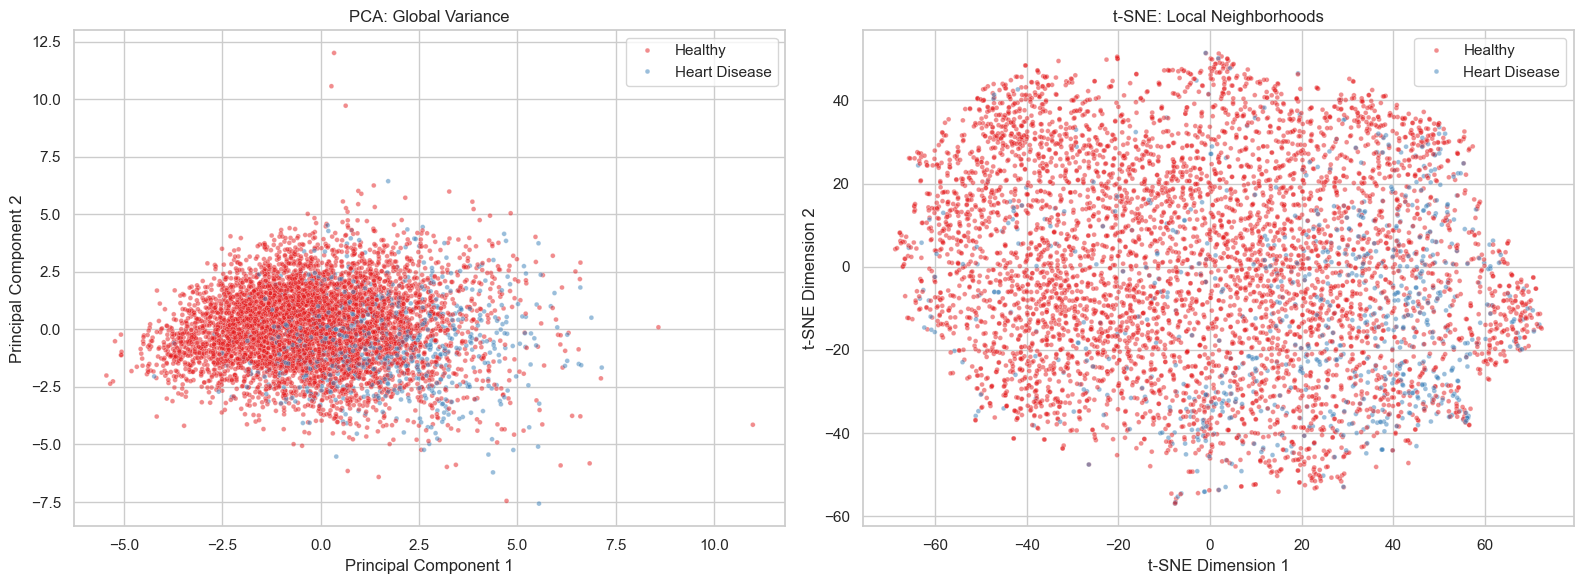

In [45]:
# PCA (Principal Component Analysis) — fitted on everyone, plotted on the sample
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_all = pca.fit_transform(X_unsup_scaled)
pca_result = pca_all[sample_idx]
print(f"Variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum():.1%}")

# t-SNE (T-distributed Stochastic Neighbor Embedding)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca', learning_rate='auto')
tsne_result = tsne.fit_transform(X_sample_unsup)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
labels = labels_all[sample_idx]

sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels, palette='Set1', ax=ax[0], alpha=0.5, s=12)
ax[0].set_title('PCA: Global Variance')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=labels, palette='Set1', ax=ax[1], alpha=0.5, s=12)
ax[1].set_title('t-SNE: Local Neighborhoods')
ax[1].set_xlabel('t-SNE Dimension 1')
ax[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
save_figure("pca_tsne_analysis.png")
plt.show()

* **PCA (29.2 % of the variance in two components):** heart disease patients sit mostly toward higher PC1 (older, heavier, higher blood pressure and HbA1c, lower eGFR), but they overlap heavily with healthy patients. No linear boundary separates the groups.
* **t-SNE:** no separate island of heart disease patients forms; they are spread through the map with a loose concentration on one side. Heart disease here is a gradual shift in many risk factors rather than a distinct patient type, consistent with the similar PR-AUC ceiling of all the strong models.

### Density and Probabilistic Clustering (DBSCAN & GMM)
DBSCAN (density-based) and a Gaussian Mixture Model (probabilistic) show how the data separates under assumptions other than standard distance-based clustering.

* **DBSCAN:** Finds clusters by data density without a pre-set number of groups. It is useful for isolating "outlier" patients with unusual clinical profiles, which distance-based algorithms like K-Means would force into a group.

* **Gaussian Mixture Model (GMM):** Clinical measurements often have overlapping distributions (e.g., borderline blood pressure or cholesterol). GMM gives each patient a *probability* of belonging to each group, so boundaries between healthy and at-risk profiles are soft rather than hard cutoffs.

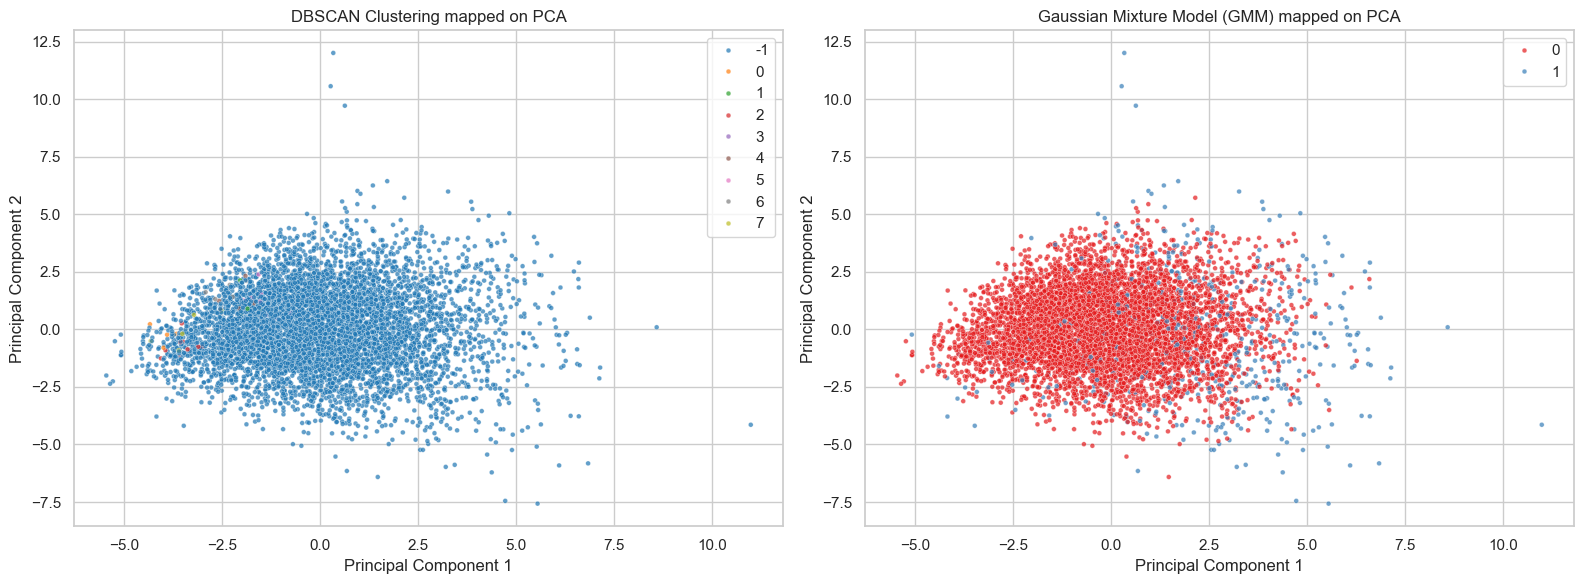

In [46]:
# eps and min_samples might need tuning depending on dataset density
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_sample_unsup)

# Gaussian Mixture Model (GMM) — we assume 2 components (healthy vs at-risk profiles)
gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
gmm_clusters = gmm.fit(X_unsup_scaled).predict(X_sample_unsup)

# Visualize the clusters using the PCA components derived earlier
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN Plot (-1 indicates noise/outliers)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=dbscan_clusters, palette='tab10', ax=ax[0], alpha=0.7, s=12)
ax[0].set_title('DBSCAN Clustering mapped on PCA')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

# GMM Plot
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=gmm_clusters, palette='Set1', ax=ax[1], alpha=0.7, s=12)
ax[1].set_title('Gaussian Mixture Model (GMM) mapped on PCA')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')

plt.tight_layout()
save_figure("dbscan_gmm_analysis.png")
plt.show()

* **DBSCAN finds no real structure** (silhouette −0.257). In 25 dimensions patients are too far apart for a single density radius: nearly everyone is labelled noise, and the few clusters are tiny.
* **GMM splits the population into a dense core and a dispersed outer group** (silhouette 0.268). The outer component holds the extreme lab and body-size values, which is where most heart disease patients and most anomalies sit.

In [47]:
from sklearn.metrics import silhouette_score

print("--- Unsupervised Model Silhouette Scores (6,000-patient sample) ---")

# DBSCAN Silhouette Score — requires at least 2 clusters
if len(set(dbscan_clusters)) > 1:
    dbscan_score = silhouette_score(X_sample_unsup, dbscan_clusters)
    print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")
else:
    print("DBSCAN Silhouette Score: N/A (Only one cluster found)")

# GMM Silhouette Score
gmm_score = silhouette_score(X_sample_unsup, gmm_clusters)
print(f"GMM Silhouette Score: {gmm_score:.4f}")

--- Unsupervised Model Silhouette Scores (6,000-patient sample) ---


DBSCAN Silhouette Score: -0.2571


GMM Silhouette Score: 0.2683


# KMeans Clustering

### Find Best Cluster Point

Finished k=2 | Score: 0.1171


Finished k=3 | Score: 0.0957


Finished k=4 | Score: 0.0853


Finished k=5 | Score: 0.0889


Finished k=6 | Score: 0.0654


Finished k=7 | Score: 0.0636


Finished k=8 | Score: 0.0634


Finished k=9 | Score: 0.0662


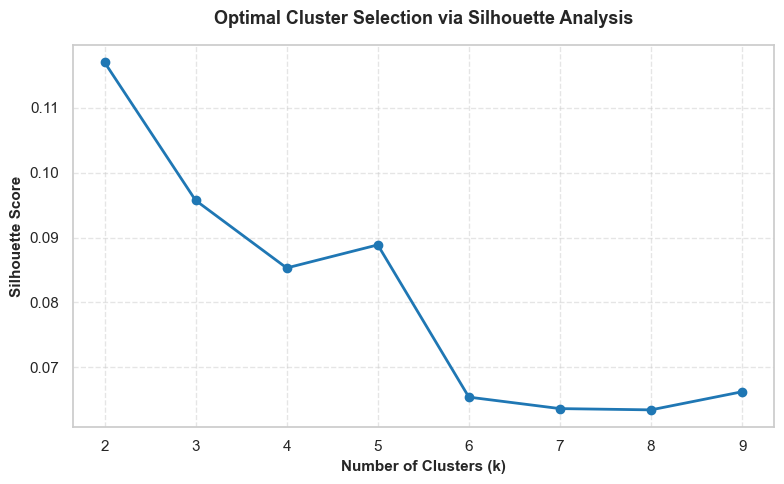

In [48]:
scores = []
for n in range(2, 10):
    km = KMeans(n_clusters=n, random_state=RANDOM_STATE, n_init=20)
    cluster_labels = km.fit_predict(X_sample_unsup)
    score = silhouette_score(X_sample_unsup, cluster_labels)
    scores.append(score)
    print(f"Finished k={n} | Score: {score:.4f}")

cluster_range = range(2, 10)
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, scores, marker='o', linewidth=2, color='#1f77b4', markersize=6)
plt.xlabel("Number of Clusters (k)", fontsize=11, fontweight='bold')
plt.ylabel("Silhouette Score", fontsize=11, fontweight='bold')
plt.title("Optimal Cluster Selection via Silhouette Analysis", fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### KMeans Clustering

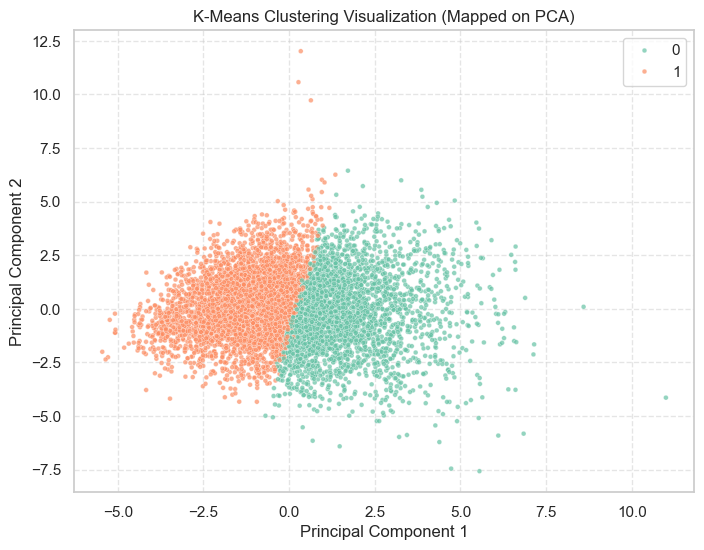

In [49]:
# Run K-Means (Using 2 clusters to see if it separates healthy vs heart disease natively)
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_unsup_scaled)

# Create a copy of the dataframe to store results without warnings
heart_data_clustered = add_custom_features(heart_data)
heart_data_clustered["Cluster"] = kmeans_clusters

plt.figure(figsize=(8, 6))
# We plot using the PCA components derived earlier for a true 2D structural view
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=kmeans_clusters[sample_idx], palette="Set2", alpha=0.7, s=12)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Visualization (Mapped on PCA)")
plt.grid(True, linestyle="--", alpha=0.5)
save_figure("kmeans_clustering.png")
plt.show()

### Cluster Profile

In [50]:
# Look at the average values of the clinical features for each cluster (with the heart disease rate)
profile_cols = numerical_features + ['heart_disease']
cluster_profiles = heart_data_clustered.groupby("Cluster")[profile_cols].mean()
cluster_profiles.loc[:, 'patients'] = heart_data_clustered['Cluster'].value_counts().sort_index()

# Transpose for easier reading
print("--- Clinical Profile of Each Cluster ---")
display(cluster_profiles.T.round(3))

--- Clinical Profile of Each Cluster ---


Cluster,0,1
age,65.850,55.161
education_level,2.992,3.599
poverty_income_ratio,2.143,2.936
bmi,33.124,26.991
waist_cm,111.011,94.965
height_cm,164.602,167.302
systolic_bp,136.274,122.921
diastolic_bp,70.223,73.504
resting_heart_rate,72.222,70.754
total_cholesterol,183.095,204.847


* **K-Means finds two metabolic profiles (k = 2 has the best silhouette, 0.117):**
    * **Cluster 0, cardiometabolic burden (10,606 patients):** mean age 66, BMI 33, waist 111 cm, systolic 136 mm Hg, HbA1c 6.5 %, eGFR 76 and 1.8 risk factors. **Heart disease: 22.3 %.**
    * **Cluster 1, younger and healthier (13,848 patients):** mean age 55, BMI 27, waist 95 cm, systolic 123 mm Hg, HbA1c 5.6 %, eGFR 93 and 0.9 risk factors. **Heart disease: 5.0 %.**
* **Without seeing any labels, the clustering separates a 4.5× difference in heart disease rate.** The burden cluster also has *lower* total cholesterol (183 vs 205 mg/dL), the same statin effect as in the correlation analysis.

# Anomaly Detection
DBSCAN finds noisy points only as a side effect; anomaly detectors are built specifically to find extreme clinical anomalies (patients with highly unusual feature combinations).

* **One-Class SVM:** Learns a soft boundary around the majority of the data without assuming a specific distribution.

* **Elliptic Envelope:** Assumes the data is roughly Gaussian (normally distributed) and draws an elliptical boundary from the data's variance.

* **Isolation Forest:** Isolates points by randomly selecting and splitting features; anomalies need fewer splits to isolate.

* **ECOD:** Flags outliers from the empirical cumulative distribution of each dimension, with no parameters to tune.

* **COPOD:** Models the joint distribution with copulas and flags points in the low-probability tails.

* **Autoencoder:** A neural network that learns to compress and reconstruct normal data; anomalies have high reconstruction errors.

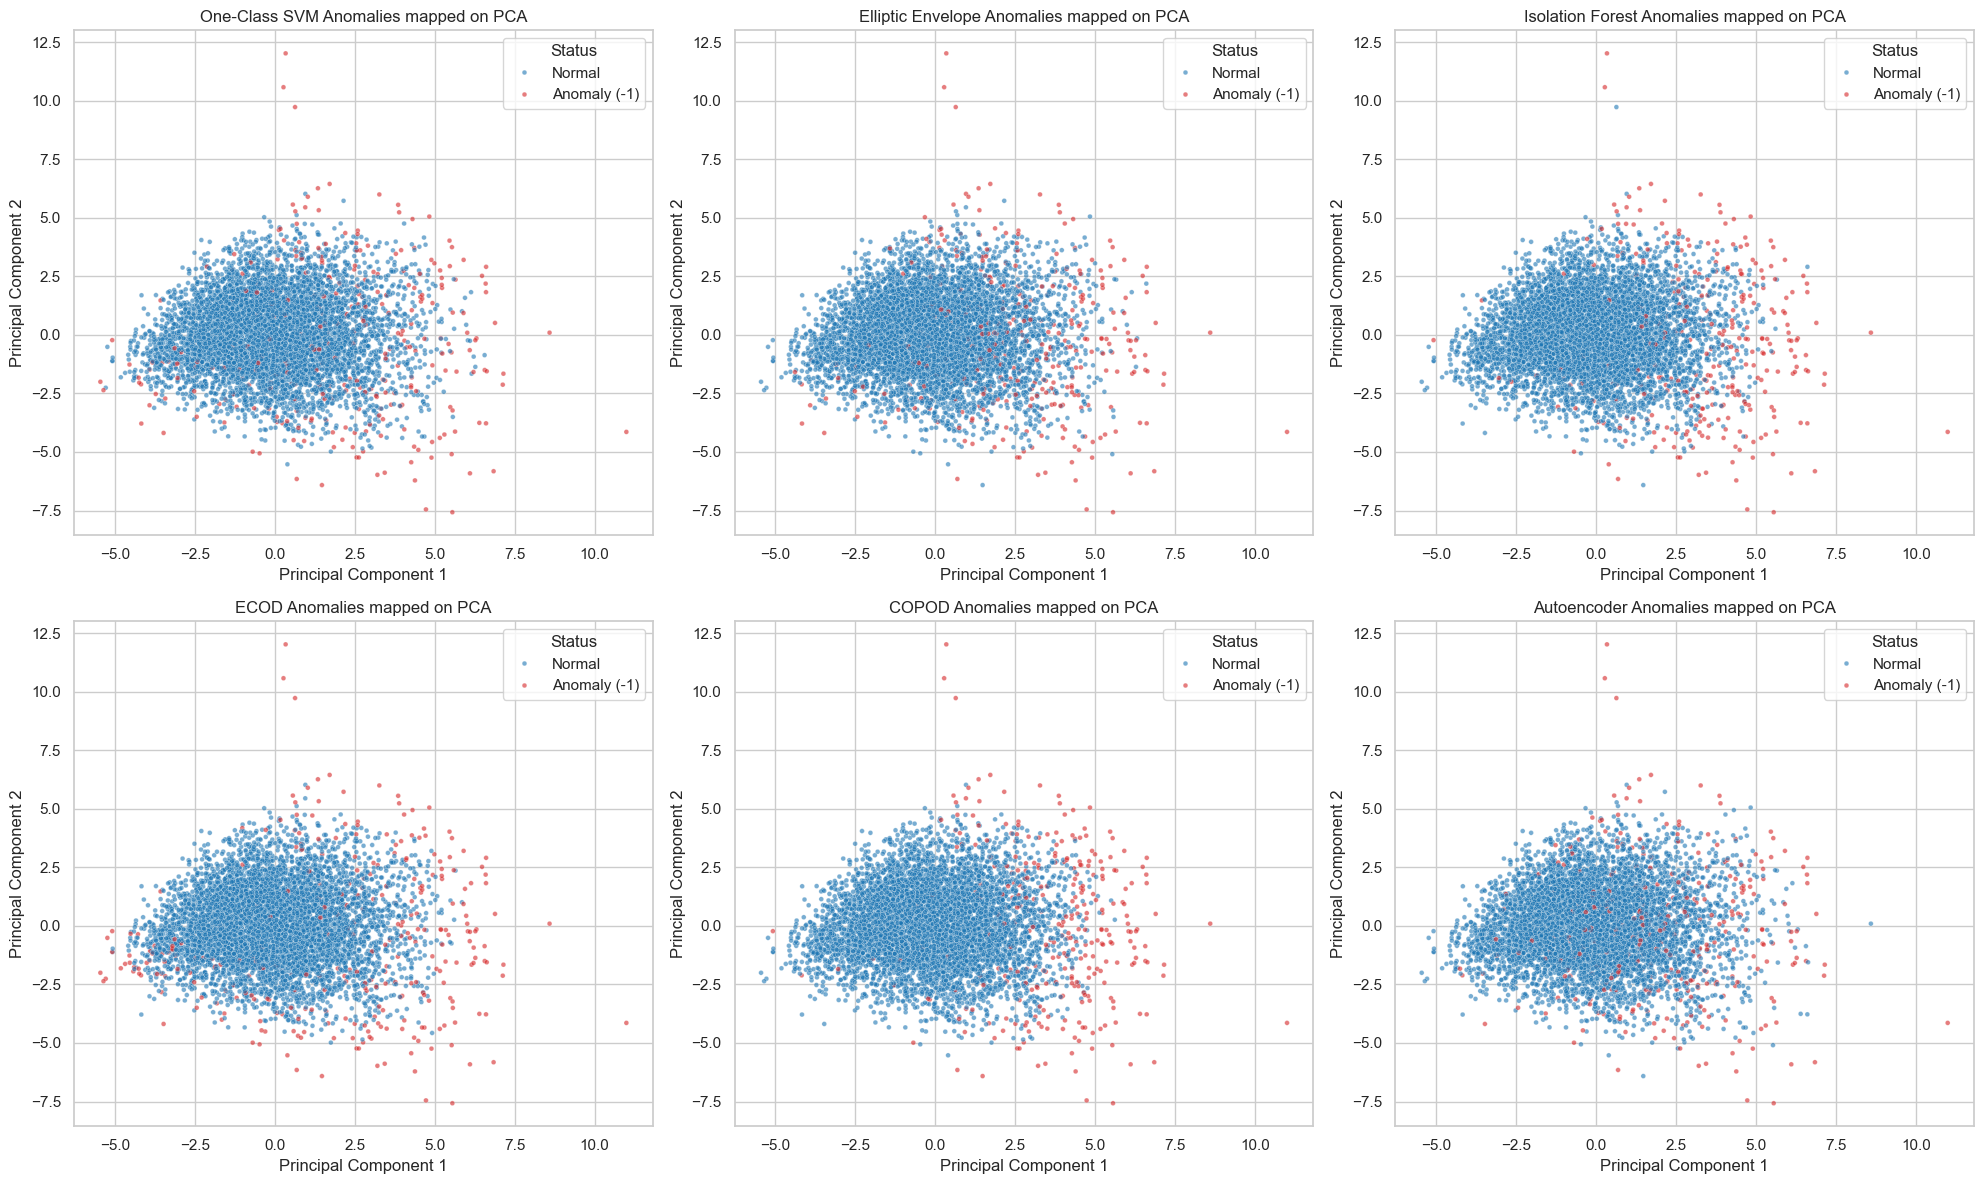

In [51]:
# On Colab: !pip install -q pyod
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.auto_encoder import AutoEncoder

# We will assume around 5% of our patient records might be extreme clinical anomalies (contamination / nu)
anomaly_fraction = 0.05

# One-Class SVM
oc_svm = OneClassSVM(nu=anomaly_fraction, kernel="rbf", gamma="scale")
svm_anomalies = oc_svm.fit_predict(X_unsup_scaled)  # Returns -1 for anomalies, 1 for normal

# Elliptic Envelope
elliptic = EllipticEnvelope(contamination=anomaly_fraction, random_state=RANDOM_STATE)
ee_anomalies = elliptic.fit_predict(X_unsup_scaled)

# Isolation Forest
iso_forest = IsolationForest(contamination=anomaly_fraction, random_state=RANDOM_STATE)
if_anomalies = iso_forest.fit_predict(X_unsup_scaled)

# ECOD — PyOD returns 1 for anomaly, 0 for normal. Mapping to -1 and 1 for consistency.
ecod = ECOD(contamination=anomaly_fraction)
ecod.fit(X_unsup_scaled)
ecod_anomalies = np.where(ecod.labels_ == 1, -1, 1)

# COPOD
copod = COPOD(contamination=anomaly_fraction)
copod.fit(X_unsup_scaled)
copod_anomalies = np.where(copod.labels_ == 1, -1, 1)

# Autoencoder
with silenced():
    ae = AutoEncoder(contamination=anomaly_fraction, random_state=RANDOM_STATE, verbose=0)
    ae.fit(X_unsup_scaled)
ae_anomalies = np.where(ae.labels_ == 1, -1, 1)

models_results = [
    ('One-Class SVM', svm_anomalies),
    ('Elliptic Envelope', ee_anomalies),
    ('Isolation Forest', if_anomalies),
    ('ECOD', ecod_anomalies),
    ('COPOD', copod_anomalies),
    ('Autoencoder', ae_anomalies)
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
ax = axes.flatten()
for i, (title, anomalies) in enumerate(models_results):
    sample_flags = anomalies[sample_idx]
    sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=sample_flags, hue_order=[1, -1],   # legend order: Normal, Anomaly
                    palette={1: '#1f77b4', -1: '#d62728'}, ax=ax[i], alpha=0.6, s=12)
    ax[i].set_title(f'{title} Anomalies mapped on PCA')
    ax[i].set_xlabel('Principal Component 1')
    ax[i].set_ylabel('Principal Component 2')
    handles, _ = ax[i].get_legend_handles_labels()
    ax[i].legend(handles=handles, labels=['Normal', 'Anomaly (-1)'], title='Status')

plt.tight_layout()
save_figure("anomaly_detection_models.png")
plt.show()

* **All six detectors flag the sparse outer edge of the PCA plot**, mostly toward higher PC1: patients with the most extreme combinations of age, body size, blood pressure and kidney markers.
* They disagree near the border of the dense core, reflecting their different assumptions (Isolation Forest's random splits, the autoencoder's reconstruction error, COPOD's tail probabilities), which is why a consensus is more reliable than any single detector.

In [52]:
anomaly_counts = []
disease_flags = heart_data['heart_disease'].values == 1

for title, anomalies in models_results:
    anomaly_count = (anomalies == -1).sum()
    anomaly_counts.append({
        'Model': title,
        'Anomalies Detected': anomaly_count,
        'Normal Patients': (anomalies == 1).sum(),
        'Anomaly %': f"{anomaly_count / len(anomalies) * 100:.2f}%",
        'Heart disease rate among anomalies': f"{disease_flags[anomalies == -1].mean() * 100:.1f}%"
    })

df_anomaly_comp = pd.DataFrame(anomaly_counts).set_index('Model')
print("=== Anomaly Detection Counts ===")
display(df_anomaly_comp)

# --- Consensus Calculation ---
all_anomalies = np.vstack([anomalies for _, anomalies in models_results])
times_flagged = (all_anomalies == -1).sum(axis=0)

print("\n=== Anomaly Consensus ===")
print(f"Patients flagged by at least 1 model: {(times_flagged >= 1).sum()}")
print(f"Patients flagged by majority (>= 3 models): {(times_flagged >= 3).sum()}")
print(f"Patients flagged by ALL 6 models (Strict Consensus): {(times_flagged == 6).sum()}")
print(f"\nOverall heart disease prevalence: {disease_flags.mean():.1%} | among strict-consensus anomalies: {disease_flags[times_flagged == 6].mean():.1%}")

=== Anomaly Detection Counts ===


,Anomalies Detected,Normal Patients,Anomaly %,Heart disease rate among anomalies
Model,,,,
One-Class SVM,1225,23229,5.01%,22.2%
Elliptic Envelope,1223,23231,5.00%,24.6%
Isolation Forest,1223,23231,5.00%,30.5%
ECOD,1223,23231,5.00%,25.3%
COPOD,1223,23231,5.00%,31.8%
Autoencoder,1223,23231,5.00%,24.8%



=== Anomaly Consensus ===
Patients flagged by at least 1 model: 2871
Patients flagged by majority (>= 3 models): 1203
Patients flagged by ALL 6 models (Strict Consensus): 288

Overall heart disease prevalence: 12.5% | among strict-consensus anomalies: 31.2%


* **The anomalies are mostly sick patients, not data errors.** Heart disease prevalence is 22–32 % among each detector's anomalies and 31.2 % among the 288 patients flagged by all six, against 12.5 % overall.
* **This shapes the cascade.** A 5 % anomaly gate would withhold predictions from many of exactly the patients a screening tool exists for, so the Stage 1 gate below uses 1 % contamination and is fitted on the training set only.

# Cascade Architecture

### Heart Disease Cascade Architecture

The cascade maximizes clinical safety and model reliability:

1. **Stage 1 (Anomaly Gate):** An **Isolation Forest** flags patients with implausible or extreme profiles (data-entry errors, rare compounding conditions). They go to manual review instead of receiving a prediction. Unlike the original heart notebook, the gate is fitted on the **training set only**, and its contamination is **1 %** rather than 5 %: the anomaly analysis above shows that a 5 % gate mostly rejects *sick* patients, exactly the people a screening tool must not turn away.
2. **Stage 2 (Supervised Classification):** Patients who pass Stage 1 are scored by the **calibrated best model**. The out-of-fold cost-optimal threshold decides "refer for a cardiology work-up", and risk bands are anchored to it: **Low** (below the threshold), **Medium** (threshold to 50 %), **High** (≥ 50 %).

In [53]:
# Stage 1 gate: numeric features only, fitted on the TRAINING set
anomaly_gate = Pipeline(steps=[
    ('engineering', FunctionTransformer(add_custom_features)),
    ('select', ColumnTransformer([('numeric', 'passthrough', numerical_features)])),
    ('scaler', RobustScaler()),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('detector', IsolationForest(n_estimators=200, contamination=0.01, random_state=RANDOM_STATE))
])
anomaly_gate.fit(X_train)

gate_flags = anomaly_gate.predict(X_test) == -1
print(f"Test patients withheld by the gate: {gate_flags.sum()} ({gate_flags.mean():.2%})")
print(f"  among heart disease patients : {gate_flags[y_test.values == 1].mean():.2%}")
print(f"  among healthy patients       : {gate_flags[y_test.values == 0].mean():.2%}")

Test patients withheld by the gate: 53 (1.08%)
  among heart disease patients : 2.62%
  among healthy patients       : 0.86%


In [54]:
# SHAP explainer for patient-level explanations (same model type logic as above)
cascade_explainer = build_shap_explainer(model_object, background)

def describe_value(column, row):
    # The patient's own value for a clinical input, in clinical units
    if column == 'blood_pressure':
        return f"{row['systolic_bp']:.0f}/{row['diastolic_bp']:.0f} mmHg"
    if column == 'cholesterol':
        return f"total {row['total_cholesterol']:.0f}, HDL {row['hdl_cholesterol']:.0f} mg/dL"
    value = row[column]
    if isinstance(value, str):
        return value
    return 'missing (imputed)' if pd.isna(value) else f"{value:.4g}"

def heart_evaluation(patients_data, model=calibrated_clf, anomaly_model=anomaly_gate, threshold=best_threshold,
                     patient_names=None, explain=True):
    # --- STAGE 1: Anomaly Detection ---
    anomalies = anomaly_model.predict(patients_data) if anomaly_model is not None else None

    # Let the AI calculate its calibrated heart disease probability (%)
    prediction_probabilities = model.predict_proba(patients_data)[:, 1]

    # If explanations are requested, prepare SHAP components
    if explain:
        X_processed = preprocessor.transform(patients_data)
        patient_shap = compute_shap_values(cascade_explainer, X_processed)
        if len(patient_shap.values.shape) == 3:
            patient_shap = patient_shap[..., 1]
        patient_values = add_custom_features(patients_data)     # raw + engineered values in clinical units

    for i in range(len(patients_data)):
        name = patient_names[i] if patient_names else f"Patient {i+1}"
        print(f"=== Diagnostic Results for {name} ===")

        # --- STAGE 1 CHECK ---
        if anomalies is not None and anomalies[i] == -1:
            print("🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!")
            print("Action: Prediction withheld. Patient requires manual clinical review due to implausible or highly unusual feature combinations.\n")
            continue # Skip Stage 2 entirely

        # --- STAGE 2: CLASSIFICATION ---
        p = prediction_probabilities[i]

        # Risk stratification anchored to the cost-optimal threshold
        if p < threshold:
            risk_level = "Low Risk"
        elif p < 0.50:
            risk_level = "Medium Risk"
        else:
            risk_level = "High Risk"

        print(f"Heart Disease Probability : {p * 100:.2f}%")
        print(f"Risk Categorization       : {risk_level}")
        print(f"Recommendation            : {'Refer for cardiology work-up (ECG, stress test)' if p >= threshold else 'Routine care'}")

        if explain:          # Add Text-based SHAP Explanations
            print("\nExplanation:")
            # Sum SHAP values per clinical input (blood pressure, cholesterol, each categorical answer), then rank them
            contributions = group_shap(patient_shap.values[i:i + 1]).iloc[0]
            ranked = contributions.loc[contributions.abs().sort_values(ascending=False).index]
            labels = [f"{c.replace('_', ' ').title()} = {describe_value(c, patient_values.iloc[i])}" for c in ranked.index]
            print("Top Contributing Factors:")
            for rank, (label, contribution) in enumerate(zip(labels[:4], ranked.values[:4])):
                print(f"{rank+1}. {label} ({contribution:+.2f})")

            # Generate and display Waterfall Plot
            print(f"\nWaterfall Plot for {name}:")
            explanation = shap.Explanation(
                values=ranked.values,
                base_values=np.ravel(patient_shap.base_values)[i] if np.ndim(patient_shap.base_values) else patient_shap.base_values,
                feature_names=labels
            )
            plt.figure(figsize=(8, 6), dpi=100)
            shap.plots.waterfall(explanation, max_display=10, show=False)
            plt.title(f'SHAP Waterfall Plot for {name}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        print("\n" + "="*50 + "\n")

We enhanced the cascade architecture by embedding SHAP (SHapley Additive exPlanations) directly into the evaluation function. As in the SHAP section, contributions are summed per clinical input (for example `Blood Pressure = 158/84 mmHg` or `Chest Pain Type = Exertional`), and each factor is printed with the patient's own value in clinical units.

# AI Prediction Test

=== Diagnostic Results for Patient A (Index 6323, true label: Healthy) ===
Heart Disease Probability : 0.88%
Risk Categorization       : Low Risk
Recommendation            : Routine care

Explanation:


Top Contributing Factors:
1. Age = 50 (-0.39)
2. Gender = Male (+0.28)
3. Resting Heart Rate = 92 (-0.25)
4. Ethnicity = Non-Hispanic White (+0.24)

Waterfall Plot for Patient A (Index 6323, true label: Healthy):


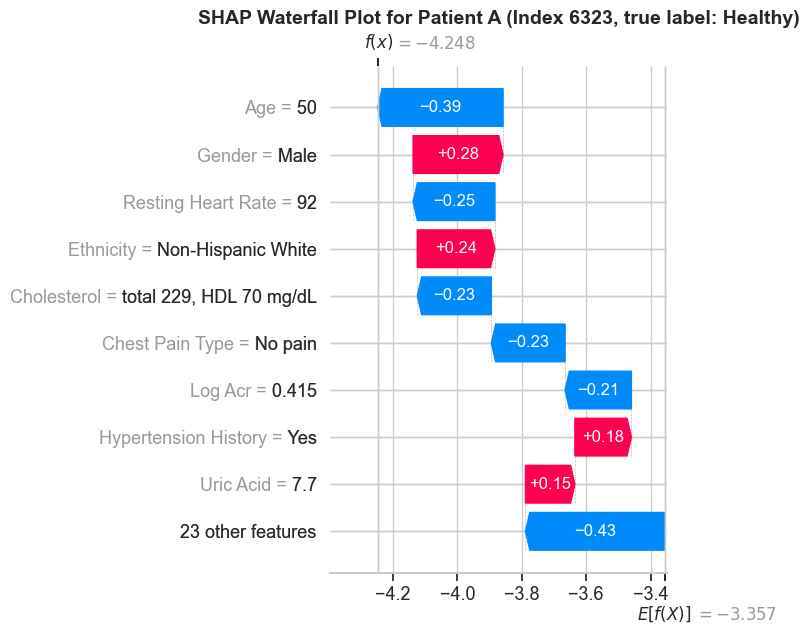



=== Diagnostic Results for Patient B (Index 11116, true label: Heart Disease) ===
Heart Disease Probability : 48.28%
Risk Categorization       : Medium Risk
Recommendation            : Refer for cardiology work-up (ECG, stress test)

Explanation:
Top Contributing Factors:
1. Severe Chest Pain = Yes (+1.13)
2. Chest Pain Type = Non-exertional (+0.89)
3. Log Acr = 2.183 (+0.39)
4. Age = 64 (+0.35)

Waterfall Plot for Patient B (Index 11116, true label: Heart Disease):


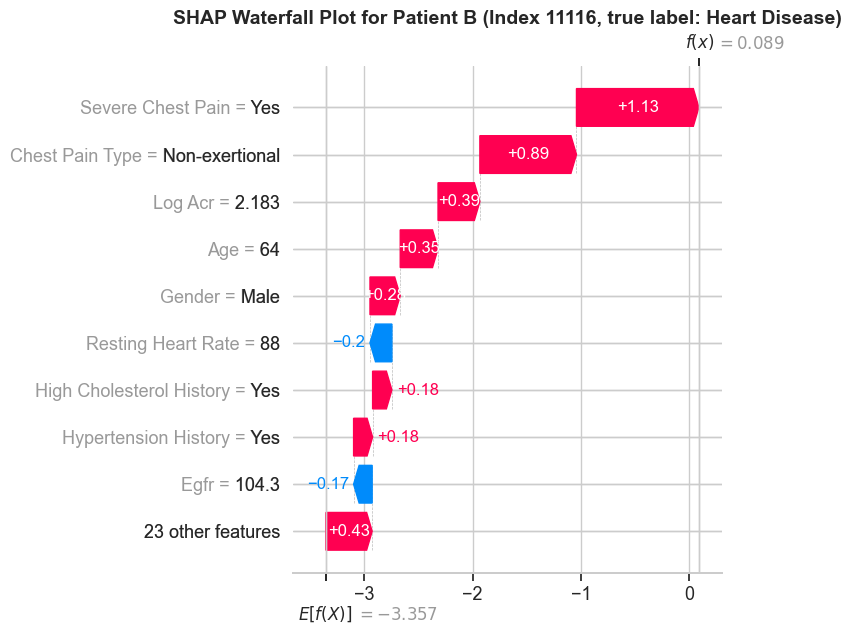



=== Diagnostic Results for Patient C (Index 16002, true label: Healthy) ===
Heart Disease Probability : 37.99%
Risk Categorization       : Medium Risk
Recommendation            : Refer for cardiology work-up (ECG, stress test)

Explanation:
Top Contributing Factors:
1. Chest Pain Type = Exertional (+1.29)
2. Age = 80 (+1.19)
3. Sob On Exertion = Yes (+0.32)
4. Gender = Female (-0.30)

Waterfall Plot for Patient C (Index 16002, true label: Healthy):


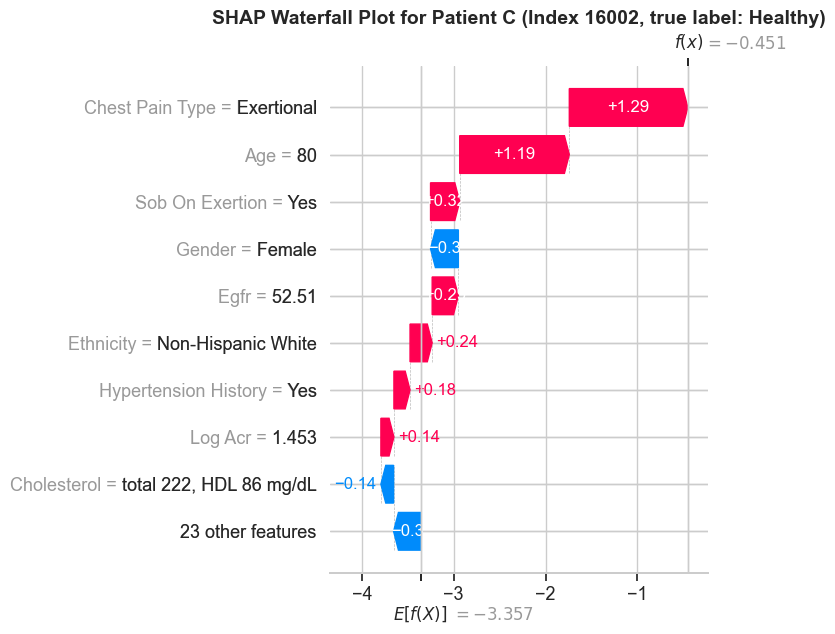

In [55]:
# Let's test the evaluation function on the first 3 patients in the test set
sample_patients = X_test.head(3)
sample_names = [f"Patient {chr(65 + i)} (Index {idx}, true label: {'Heart Disease' if y_test.loc[idx] else 'Healthy'})"
                for i, idx in enumerate(sample_patients.index)]

heart_evaluation(sample_patients, patient_names=sample_names, explain=True)

# Save and Test Final Model (Joblib)
We save the calibrated model, the Stage 1 anomaly gate and a `metadata.json` (threshold, feature lists, test metrics) to `models/`, then reload them and test with mock patients.

*Note:* the pipelines reference `add_custom_features`, defined in this notebook. Any script that loads them must define the same function first: `src.predict` does this automatically (via `src.data.register_notebook_functions`), and `python -m src.train` rebuilds the same artifacts from the command line.

In [56]:
import joblib

model_filename = os.path.join(models_dir, "heart_disease_calibrated_model.joblib")
gate_filename = os.path.join(models_dir, "heart_disease_anomaly_gate.joblib")
metadata_filename = os.path.join(models_dir, "metadata.json")

joblib.dump(calibrated_clf, model_filename)
joblib.dump(anomaly_gate, gate_filename)

metadata = {
    'dataset': 'HEART_NHANES.csv (CDC NHANES 2007-March 2020, examined adults aged 40+)',
    'target': 'heart_disease: doctor-diagnosed coronary heart disease, angina, heart attack or congestive heart failure',
    'best_model': best_model_name,
    'selection_rule': 'one-standard-error rule on 5-fold CV PR-AUC among CPU-deployable models',
    'optimal_threshold': best_threshold,
    'cost_weights': {'false_negative': FN_COST, 'false_positive': FP_COST},
    'risk_bands': {'low': f'< {best_threshold:.4f}', 'medium': f'{best_threshold:.4f} - 0.50', 'high': '>= 0.50'},
    'raw_input_columns': X.columns.tolist(),
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'test_metrics': {'roc_auc': roc_auc_score(y_test, calib_probas), 'pr_auc': average_precision_score(y_test, calib_probas),
                     'brier_score': brier_calibrated, 'recall_at_threshold': recall_score(y_test, sim_preds_best),
                     'precision_at_threshold': precision_score(y_test, sim_preds_best)},
    'bootstrap_confidence_intervals': confidence_intervals,
    'training_rows': len(X_train), 'test_rows': len(X_test), 'prevalence': float(y.mean())
}
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2, default=float)

print(f"[SAVED] Calibrated Model -> {model_filename}")
print(f"[SAVED] Anomaly Gate     -> {gate_filename}")
print(f"[SAVED] Metadata         -> {metadata_filename}")

[SAVED] Calibrated Model -> E:\Disease-Risk-Prediction\heart\tabular\models\heart_disease_calibrated_model.joblib
[SAVED] Anomaly Gate     -> E:\Disease-Risk-Prediction\heart\tabular\models\heart_disease_anomaly_gate.joblib
[SAVED] Metadata         -> E:\Disease-Risk-Prediction\heart\tabular\models\metadata.json


[LOADED] Successfully loaded model from E:\Disease-Risk-Prediction\heart\tabular\models\heart_disease_calibrated_model.joblib

=== Loaded Joblib Model Test ===


=== Diagnostic Results for Patient A (High Risk Mock) ===
Heart Disease Probability : 92.38%
Risk Categorization       : High Risk
Recommendation            : Refer for cardiology work-up (ECG, stress test)

Explanation:
Top Contributing Factors:
1. Chest Pain Type = Exertional (+1.29)
2. Severe Chest Pain = Yes (+1.13)
3. Age = 67 (+0.51)
4. Family History Chd = Yes (+0.46)

Waterfall Plot for Patient A (High Risk Mock):


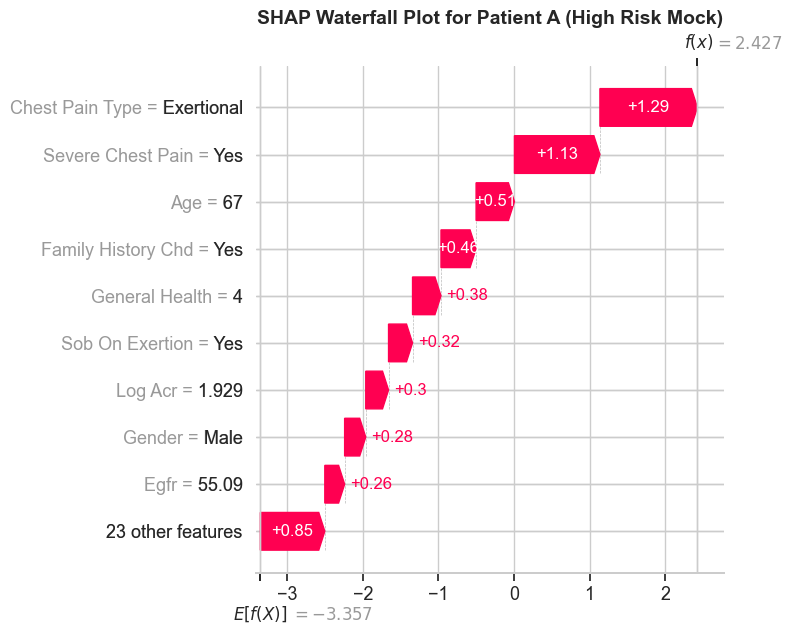



=== Diagnostic Results for Patient B (Low Risk Mock) ===
Heart Disease Probability : 0.00%
Risk Categorization       : Low Risk
Recommendation            : Routine care

Explanation:
Top Contributing Factors:
1. Age = 45 (-0.65)
2. Gender = Female (-0.30)
3. General Health = 2 (-0.28)
4. Waist Cm = 84 (+0.25)

Waterfall Plot for Patient B (Low Risk Mock):


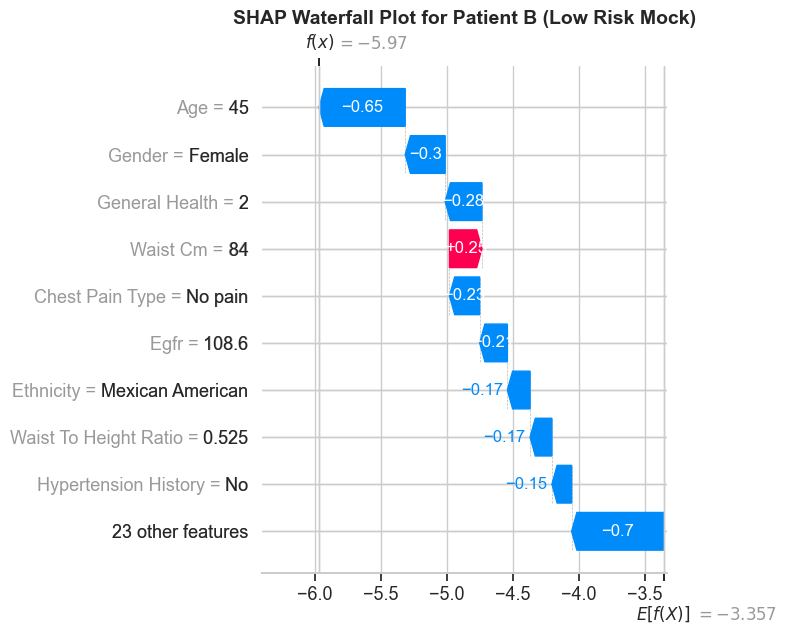



=== Diagnostic Results for Patient C (Extreme Anomaly Mock) ===
🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!
Action: Prediction withheld. Patient requires manual clinical review due to implausible or highly unusual feature combinations.



In [57]:
# Test with mock patients
loaded_model = joblib.load(model_filename)
loaded_gate = joblib.load(gate_filename)
print(f"[LOADED] Successfully loaded model from {model_filename}\n")

mock_patients = pd.DataFrame([
    {
        # Patient A (High Risk Mock: 67-year-old smoker with diabetes, hypertension and exertional chest pain)
        "age": 67.0, "gender": "Male", "ethnicity": "Non-Hispanic White", "education_level": 2.0, "poverty_income_ratio": 1.3,
        "bmi": 31.5, "waist_cm": 112.0, "height_cm": 175.0, "systolic_bp": 158.0, "diastolic_bp": 84.0, "resting_heart_rate": 82.0,
        "total_cholesterol": 240.0, "hdl_cholesterol": 34.0, "hba1c": 7.9, "serum_creatinine": 1.4, "uric_acid": 7.6,
        "albumin_creatinine_ratio": 85.0, "white_blood_cells": 8.9, "hemoglobin": 13.4, "rdw": 14.8,
        "smoking_status": "Current", "physically_active": "No", "hypertension_history": "Yes", "high_cholesterol_history": "Yes",
        "diabetes_status": "Yes", "stroke_history": "No", "family_history_chd": "Yes", "general_health": 4.0,
        "chest_pain_type": "Exertional", "severe_chest_pain": "Yes", "sob_on_exertion": "Yes"
    },
    {
        # Patient B (Low Risk Mock: active 45-year-old never-smoker, no chest pain, normal labs)
        "age": 45.0, "gender": "Female", "ethnicity": "Mexican American", "education_level": 4.0, "poverty_income_ratio": 3.5,
        "bmi": 24.5, "waist_cm": 84.0, "height_cm": 160.0, "systolic_bp": 114.0, "diastolic_bp": 72.0, "resting_heart_rate": 66.0,
        "total_cholesterol": 182.0, "hdl_cholesterol": 62.0, "hba1c": 5.3, "serum_creatinine": 0.7, "uric_acid": 4.2,
        "albumin_creatinine_ratio": 6.0, "white_blood_cells": 6.1, "hemoglobin": 13.3, "rdw": 12.9,
        "smoking_status": "Never", "physically_active": "Yes", "hypertension_history": "No", "high_cholesterol_history": "No",
        "diabetes_status": "No", "stroke_history": "No", "family_history_chd": "No", "general_health": 2.0,
        "chest_pain_type": "No pain", "severe_chest_pain": "No", "sob_on_exertion": "No"
    },
    {
        # Patient C (Extreme Anomaly Mock: Impossible values to trigger Stage 1 Rejection)
        "age": 150.0, "gender": "Male", "ethnicity": "Other Hispanic", "education_level": 1.0, "poverty_income_ratio": 0.1,
        "bmi": 95.0, "waist_cm": 250.0, "height_cm": 250.0, "systolic_bp": 300.0, "diastolic_bp": 200.0, "resting_heart_rate": 220.0,
        "total_cholesterol": 900.0, "hdl_cholesterol": 5.0, "hba1c": 20.0, "serum_creatinine": 25.0, "uric_acid": 20.0,
        "albumin_creatinine_ratio": 50000.0, "white_blood_cells": 90.0, "hemoglobin": 25.0, "rdw": 40.0,
        "smoking_status": "Current", "physically_active": "No", "hypertension_history": "Yes", "high_cholesterol_history": "Yes",
        "diabetes_status": "Yes", "stroke_history": "Yes", "family_history_chd": "Yes", "general_health": 5.0,
        "chest_pain_type": "Exertional", "severe_chest_pain": "Yes", "sob_on_exertion": "Yes"
    }
])[X.columns]

print("=== Loaded Joblib Model Test ===")
heart_evaluation(
    patients_data=mock_patients,
    model=loaded_model,
    anomaly_model=loaded_gate,
    patient_names=["Patient A (High Risk Mock)", "Patient B (Low Risk Mock)", "Patient C (Extreme Anomaly Mock)"]
)

# Conclusion
This project built a robust, interpretable and clinically actionable pipeline for heart disease screening. Moving from the 920-patient UCI file to **24,454 NHANES adults** made every result statistically meaningful: the test set alone has 4,891 patients and 610 cases.

**Key Achievements & Methodologies:**
* **A larger, cleaner dataset:** built reproducibly from six CDC NHANES cycles (2007–2020) with every survey skip pattern resolved, 31 clinical features (vitals, lipids, HbA1c, kidney markers, blood counts, history, Rose chest-pain questionnaire) and 12.5 % prevalence.
* **Clinical feature engineering:** pulse pressure, non-HDL cholesterol, the total/HDL ratio, waist-to-height ratio, eGFR (CKD-EPI 2021), log albumin-creatinine ratio and a risk-factor count.
* **17 classifiers, compared like for like:** 9 baselines and 8 modern models (CatBoost, Explainable Boosting, TabNet, FT-Transformer, RealMLP, TabM, TabPFN, Stacking Ensemble), all tuned on 5-fold CV PR-AUC with oversampling as a tunable option. Cross-validation turned SMOTE off for every model.
* **Honest model selection:** TabPFN scored highest (CV PR-AUC 0.579, test ROC-AUC 0.886), but the top ten models are within about one standard error. The one-SE rule, applied to CPU-deployable models, chose **Logistic Regression** (CV PR-AUC 0.567, test ROC-AUC 0.880, PR-AUC 0.555), giving up 0.008 test PR-AUC for a transparent, instant, 13 MB model.
* **Calibrated, cost-optimised decisions:** isotonic calibration (Brier 0.0767 vs 0.1092 for the prevalence baseline) and an out-of-fold cost-based threshold of **0.200** (5:1 cost of a missed case). On the test set this catches **73.1 % of heart disease (95 % CI 69.6–76.7 %)** at 41.6 % precision and 85.4 % specificity.
* **Explainability:** permutation importance and SHAP both put age, chest-pain symptoms, sex, self-rated health and risk-factor history on top. SHAP is grouped by clinical input so that engineered combinations (pulse pressure, non-HDL) don't show misleading opposite-signed parts, and every patient explanation is printed in clinical units.
* **Unsupervised insights:** K-Means separates a cardiometabolic-burden cluster (22.3 % heart disease) from a younger, healthier one (5.0 %) without labels, and the six anomaly detectors show that extreme profiles are mostly sick patients (31.2 % prevalence among consensus anomalies).
* **Two-stage explainable cascade:** a 1 % Isolation Forest gate trained only on the training set (it withholds 1.1 % of test patients and correctly rejects impossible values), followed by the calibrated model with risk bands anchored to the optimal threshold and a SHAP explanation for every prediction. The model, gate and metadata are saved to `models/` and reload cleanly.

**Limitations:**
* The target is **self-reported diagnosed** heart disease in **cross-sectional** data. Treatment shows up in the inputs (statins lower cholesterol, blood-pressure drugs lower pressure), so the model recognises diagnosed disease and is not a prospective 10-year risk score like the Pooled Cohort Equations.
* There is no ECG, troponin, echocardiography or imaging, which caps discrimination at a PR-AUC of about 0.56 for every model tested.
* The gate still withholds heart disease patients at 3× the rate of healthy ones (2.6 % vs 0.9 %), so withheld patients should be treated as priority reviews, not dismissals.

**Future Work / Next Steps:**
* **Wire the Streamlit app and the top-level cascade** to `src.predict.predict_single`, which already serves this model and gate.
* **Longitudinal validation** with the NHANES linked mortality files, to test whether the model's probabilities predict future cardiovascular deaths and not only past diagnoses.
* **External validation** on hospital data with ECG results, and a model variant without treatment-affected inputs for untreated screening populations.